# HOUSEKEEPING

In [1]:
import sys
import os
sys.path.append('/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/')

In [2]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats 
from scipy.stats import shapiro , kstest, mannwhitneyu, ttest_rel
import torch
from torch import nn
from datasets.datasets import MRIDataset, STAREDataset

from helper_func.analyis_helper import clean_df, plot_boxplots, visualize, generate_batch_views, visualize_views

In [3]:
def apply_test(A, B, tests):
    NCR_results_dice = tests(A['dice_NCR'], B['dice_NCR'])
    ET_results_dice = tests(A['dice_ET'], B['dice_ET'])
    ED_results_dice = tests(A['dice_ED'], B['dice_ED'])
    
    NCR_results_HD = tests(A['hausdorff_NCR'], B['hausdorff_NCR'])
    ET_results_HD = tests(A['hausdorff_ET'], B['hausdorff_ET'])
    ED_results_HD = tests(A['hausdorff_ED'], B['hausdorff_ED'])
    return f'''
    Results for NCR dice {NCR_results_dice} \n
    Results for ET dice {ET_results_dice} \n
    Results for ED dice {ED_results_dice} \n

    Results for NCR HD {NCR_results_HD} \n
    Results for ET HD {ET_results_HD} \n
    Results for ED HD {ED_results_HD} \n
                '''

## MAIN ANALYSIS

In [5]:
_EXP_path = "/scratch/radjoe/Projects/Experiments/SAMEXP/results/boxes/SSA_boxes.csv"
_TTA_path =  "/scratch-second/radjoe_data/RESULT_TO_USE/BraTS_SSA/SSA_boxes.csv"

In [5]:
GLI_pred_path = "/scratch-second/radjoe_data/RESULT_TO_USE/BraTS_GLI/boxes"
SSA_pred_path = "/scratch-second/radjoe_data/RESULT_TO_USE/BraTS_SSA/boxes"

In [6]:
TTA_pred_path = "/scratch-second/radjoe_data/one_box_prompt_res/E-Meeting/BraTS_SSA/"

In [7]:
GLI_label_path = "/scratch_net/ken/radjoe/BraTS/Validation/labels_UNN"
SSA_label_path = "/scratch_net/ken/radjoe/Preprocess_BraTS2023_SSA_Training/labels_UNN"

In [8]:
GLI_video_path = "/scratch_net/ken/radjoe/BraTS/Validation/images_UNN"
SSA_video_path = "/scratch_net/ken/radjoe/Preprocess_BraTS2023_SSA_Training/images_UNN"

In [9]:
GLI_TTA_path = "/scratch/radjoe/Projects/Experiments/SAMEXP/logs/decoder_only_adapter_example_tta_africa/logs/BraTS_GLI/SSA_boxes.csv"
SSA_TTA_path = "/scratch/radjoe/Projects/Experiments/SAMEXP/logs/decoder_only_adapter_example_tta_gli/logs/BraTS_GLI/SSA_boxes.csv"


In [10]:
GLI_TTA_df = pd.read_csv(GLI_TTA_path)
GLI_TTA_df = clean_df(GLI_TTA_df, True, 'brats')
GLI_TTA_df.describe()

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/radjoe/Projects/Experiments/SAMEXP/logs/decoder_only_adapter_example_tta_africa/logs/BraTS_GLI/SSA_boxes.csv'

In [11]:
SSA_TTA_df = pd.read_csv(SSA_TTA_path)
SSA_TTA_df = clean_df(SSA_TTA_df, True, 'brats')
SSA_TTA_df.describe()

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/radjoe/Projects/Experiments/SAMEXP/logs/decoder_only_adapter_example_tta_gli/logs/BraTS_GLI/SSA_boxes.csv'

In [12]:
_EXP_df = pd.read_csv(_EXP_path)
_EXP_df = clean_df(_EXP_df, True, 'brats')
_EXP_df.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000
mean,0.479278,0.503395,0.623165,53.407085,54.678798,58.872160,0.799805,0.540048,0.874705,0.395508,0.544125,0.515808
std,0.254477,0.226687,0.187326,23.760774,19.530031,20.102005,0.308847,0.243736,0.175250,0.235916,0.233932,0.194618
min,0.000000,0.041818,0.094539,4.123106,6.708204,5.099020,0.000000,0.046593,0.270796,0.000000,0.023115,0.051272
25%,0.261659,0.384747,0.462004,40.620193,46.141087,46.002174,0.750242,0.387759,0.837359,0.216812,0.388974,0.393444
50%,0.521192,0.535710,0.664898,51.234753,57.503906,62.450783,0.952899,0.521408,0.958861,0.416583,0.573227,0.530764
75%,0.704525,0.675224,0.773980,68.873779,67.748055,72.208031,0.995102,0.736595,0.981147,0.574851,0.757598,0.660459
max,0.896629,0.871017,0.863240,112.259521,94.435165,108.331268,1.000000,0.945621,0.998303,0.934025,0.879502,0.855497


In [13]:
_EXP_df = pd.read_csv(_EXP_path)
_EXP_df = clean_df(_EXP_df, True, 'brats')
_EXP_df.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000
mean,0.479278,0.503395,0.623165,53.407085,54.678798,58.872160,0.799805,0.540048,0.874705,0.395508,0.544125,0.515808
std,0.254477,0.226687,0.187326,23.760774,19.530031,20.102005,0.308847,0.243736,0.175250,0.235916,0.233932,0.194618
min,0.000000,0.041818,0.094539,4.123106,6.708204,5.099020,0.000000,0.046593,0.270796,0.000000,0.023115,0.051272
25%,0.261659,0.384747,0.462004,40.620193,46.141087,46.002174,0.750242,0.387759,0.837359,0.216812,0.388974,0.393444
50%,0.521192,0.535710,0.664898,51.234753,57.503906,62.450783,0.952899,0.521408,0.958861,0.416583,0.573227,0.530764
75%,0.704525,0.675224,0.773980,68.873779,67.748055,72.208031,0.995102,0.736595,0.981147,0.574851,0.757598,0.660459
max,0.896629,0.871017,0.863240,112.259521,94.435165,108.331268,1.000000,0.945621,0.998303,0.934025,0.879502,0.855497


In [14]:
_TTA_df = pd.read_csv(_TTA_path)
_TTA_df = clean_df(_TTA_df, True, 'brats')
_TTA_df.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000
mean,0.484807,0.513492,0.569660,46.458240,47.753076,61.033864,0.646244,0.604839,0.735727,0.456838,0.480004,0.495007
std,0.285053,0.208510,0.167965,26.045599,14.205489,17.747369,0.335781,0.210149,0.217784,0.288166,0.237254,0.166381
min,0.000000,0.044461,0.003239,4.128942,5.385165,30.801785,0.000000,0.028034,0.014085,0.000000,0.075821,0.001830
25%,0.237404,0.389245,0.457476,29.411545,38.639338,46.786577,0.384091,0.537544,0.613569,0.177562,0.302930,0.435371
50%,0.560122,0.537065,0.607888,42.859657,49.648766,57.463032,0.794132,0.658688,0.792046,0.524024,0.450004,0.519677
75%,0.709091,0.678375,0.697815,62.659359,58.470867,76.387814,0.931637,0.744100,0.901982,0.686832,0.682925,0.616348
max,0.859978,0.832684,0.851488,100.171349,80.956779,97.708748,1.000000,0.872817,0.987857,0.876981,0.923284,0.753922


In [15]:
_TTA_df = pd.read_csv(_TTA_path)
_TTA_df = clean_df(_TTA_df, True, 'brats')
_TTA_df.describe()


,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000
mean,0.484807,0.513492,0.569660,46.458240,47.753076,61.033864,0.646244,0.604839,0.735727,0.456838,0.480004,0.495007
std,0.285053,0.208510,0.167965,26.045599,14.205489,17.747369,0.335781,0.210149,0.217784,0.288166,0.237254,0.166381
min,0.000000,0.044461,0.003239,4.128942,5.385165,30.801785,0.000000,0.028034,0.014085,0.000000,0.075821,0.001830
25%,0.237404,0.389245,0.457476,29.411545,38.639338,46.786577,0.384091,0.537544,0.613569,0.177562,0.302930,0.435371
50%,0.560122,0.537065,0.607888,42.859657,49.648766,57.463032,0.794132,0.658688,0.792046,0.524024,0.450004,0.519677
75%,0.709091,0.678375,0.697815,62.659359,58.470867,76.387814,0.931637,0.744100,0.901982,0.686832,0.682925,0.616348
max,0.859978,0.832684,0.851488,100.171349,80.956779,97.708748,1.000000,0.872817,0.987857,0.876981,0.923284,0.753922


In [16]:
_TTA_df = pd.read_csv(_TTA_path)
_TTA_df = clean_df(_TTA_df, True, 'brats')
_TTA_df.describe()


,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000
mean,0.484807,0.513492,0.569660,46.458240,47.753076,61.033864,0.646244,0.604839,0.735727,0.456838,0.480004,0.495007
std,0.285053,0.208510,0.167965,26.045599,14.205489,17.747369,0.335781,0.210149,0.217784,0.288166,0.237254,0.166381
min,0.000000,0.044461,0.003239,4.128942,5.385165,30.801785,0.000000,0.028034,0.014085,0.000000,0.075821,0.001830
25%,0.237404,0.389245,0.457476,29.411545,38.639338,46.786577,0.384091,0.537544,0.613569,0.177562,0.302930,0.435371
50%,0.560122,0.537065,0.607888,42.859657,49.648766,57.463032,0.794132,0.658688,0.792046,0.524024,0.450004,0.519677
75%,0.709091,0.678375,0.697815,62.659359,58.470867,76.387814,0.931637,0.744100,0.901982,0.686832,0.682925,0.616348
max,0.859978,0.832684,0.851488,100.171349,80.956779,97.708748,1.000000,0.872817,0.987857,0.876981,0.923284,0.753922


In [17]:
GLI_best =  _EXP_df[(_EXP_df['dice_ET'] > 0.70) & (_EXP_df['dice_NCR'] > 0.70)& (_EXP_df['dice_ED'] > 0.70)]
GLI_best.describe() 

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
mean,0.704699,0.807639,0.791001,24.322656,59.013771,58.679334,0.963320,0.871644,0.981135,0.555960,0.767205,0.666069
std,0.004491,0.070056,0.069763,21.191100,1.436050,15.928065,0.032092,0.059314,0.013263,0.012936,0.144162,0.096834
min,0.700297,0.732415,0.724011,8.306623,57.835976,42.663792,0.939679,0.813855,0.967417,0.543879,0.603078,0.578466
25%,0.702411,0.775950,0.754882,12.308065,58.213892,50.759773,0.945054,0.841280,0.974757,0.549136,0.714136,0.614081
50%,0.704525,0.819485,0.785753,16.309507,58.591808,58.855755,0.950429,0.868704,0.982097,0.554393,0.825193,0.649695
75%,0.706900,0.845251,0.824496,32.330672,59.602669,66.687105,0.975141,0.900539,0.987994,0.562001,0.849268,0.709871
max,0.709274,0.871017,0.863240,48.351837,60.613529,74.518456,0.999853,0.932374,0.993891,0.569608,0.873342,0.770046


In [18]:
GLI_TTA_best =  GLI_TTA_df[(GLI_TTA_df['dice_ET'] > 0.0) & (GLI_TTA_df['dice_NCR'] > 0.70)& (GLI_TTA_df['dice_ED'] > 0.70)]
GLI_TTA_best

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
11,BraTS-GLI-00511-001.npy,0.775312,0.771228,0.816236,4.123106,9.643651,7.000000,0.981944,0.954058,0.865664,0.640525,0.647201,0.772147
14,BraTS-GLI-00599-000.npy,0.762396,0.737601,0.743455,6.985644,31.898273,5.744563,0.684554,0.949098,0.686520,0.860213,0.603188,0.810688
28,BraTS-GLI-01355-000.npy,0.820152,0.759523,0.843375,1.732051,13.601471,9.000000,0.741525,0.972301,0.920503,0.917431,0.623152,0.778173


In [28]:
SSA_best =  SSA_TTA_df[(SSA_TTA_df['dice_ET'] > 0.70) & (SSA_TTA_df['dice_NCR'] > 0.70)& (SSA_TTA_df['dice_ED'] > 0.70)]
SSA_best

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET


In [20]:
SSA_worst =  _TTA_df[(_TTA_df['dice_ET'] < 0.60) & (_TTA_df['dice_NCR'] < 0.60)& (_TTA_df['dice_ED'] < 0.60)]
SSA_worst

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
3,BraTS-SSA-00010-000.npy,0.324411,0.391362,0.427187,51.707352,62.236240,55.443665,0.205838,0.588529,0.358043,0.765210,0.293151,0.529427
8,BraTS-SSA-00025-000.npy,0.544844,0.387128,0.577068,32.186165,23.895607,62.273590,0.819697,0.527129,0.659110,0.408028,0.305887,0.513189
9,BraTS-SSA-00026-000.npy,0.430728,0.367767,0.470256,98.162109,35.510563,86.742157,0.828838,0.478349,0.835556,0.290969,0.298713,0.327204
11,BraTS-SSA-00037-000.npy,0.057471,0.462177,0.243173,70.290443,47.188435,57.463032,0.361842,0.390135,0.896280,0.031215,0.566849,0.140669
12,BraTS-SSA-00041-000.npy,0.188934,0.549829,0.595051,29.832869,38.678158,40.311287,0.873642,0.427374,0.900104,0.105920,0.770641,0.444430
21,BraTS-SSA-00068-000.npy,0.044090,0.544181,0.373789,35.385017,29.885605,48.052055,0.096653,0.547958,0.313507,0.028559,0.540456,0.462772
22,BraTS-SSA-00074-000.npy,0.229376,0.422656,0.375510,33.000000,38.600517,43.865696,0.951762,0.622236,0.669425,0.130402,0.320013,0.260942
23,BraTS-SSA-00076-000.npy,0.029148,0.567669,0.599898,57.949978,42.860237,49.707108,0.037453,0.852203,0.615508,0.023858,0.425578,0.585060
27,BraTS-SSA-00092-000.npy,0.044537,0.137690,0.003239,80.240265,35.440090,91.630508,1.000000,0.138022,0.014085,0.022776,0.137360,0.001830
31,BraTS-SSA-00112-000.npy,0.155370,0.222825,0.413364,26.645824,68.073486,67.563667,0.888350,0.371480,0.744133,0.085129,0.159142,0.286164


In [21]:
GLI_worst =  _EXP_df[(_EXP_df['dice_ET'] < 0.60) & (_EXP_df['dice_NCR'] < 0.60)& (_EXP_df['dice_ED'] < 0.60)]
GLI_worst

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
3,BraTS-GLI-00064-000.npy,0.424055,0.160020,0.370421,58.156677,57.671482,62.201286,0.431800,0.144950,0.571901,0.416583,0.178589,0.273920
22,BraTS-GLI-00557-000.npy,0.476692,0.227588,0.301008,84.821571,76.668114,92.242592,0.963408,0.146160,0.945382,0.316697,0.513870,0.179001
30,BraTS-GLI-00715-000.npy,0.521192,0.563373,0.570903,68.759697,53.037724,66.057159,0.996773,0.634470,0.988056,0.352843,0.506605,0.401424
33,BraTS-GLI-00742-000.npy,0.247683,0.542080,0.357817,70.781357,62.681736,66.591660,0.274798,0.498770,0.602698,0.225438,0.593627,0.254437
39,BraTS-GLI-01147-000.npy,0.183634,0.090895,0.434689,64.671867,71.874893,77.316559,1.000000,0.262861,0.997666,0.101100,0.054948,0.277882
46,BraTS-GLI-01218-000.npy,0.041918,0.465276,0.392128,40.865635,74.759613,38.975594,0.917889,0.652361,0.934513,0.021449,0.361581,0.248120
48,BraTS-GLI-01279-000.npy,0.000000,0.082263,0.230216,80.624435,61.406010,93.861870,0.000000,0.046593,0.270796,0.000000,0.350908,0.200213
49,BraTS-GLI-01291-000.npy,0.209188,0.473735,0.441783,68.873779,76.845940,82.238670,0.128347,0.623926,0.962357,0.565164,0.381822,0.286698
56,BraTS-GLI-01504-000.npy,0.202824,0.165373,0.094539,49.424648,72.535164,76.345596,0.113764,0.387759,0.605463,0.934025,0.105098,0.051272


In [22]:
GLI_mid = _EXP_df[
    (_EXP_df['dice_ET'].between(0.6, 0.90)) &
    (_EXP_df['dice_NCR'].between(0.55, 0.80)) &
    (_EXP_df['dice_ED'].between(0.55, 0.80))
]
GLI_mid

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
1,BraTS-GLI-00036-001.npy,0.771229,0.683193,0.811528,68.098442,84.172440,63.346672,0.997730,0.794622,0.925736,0.628540,0.599172,0.722405
6,BraTS-GLI-00172-000.npy,0.700297,0.732415,0.724011,48.351837,57.835976,42.663792,0.950429,0.932374,0.967417,0.554393,0.603078,0.578466
8,BraTS-GLI-00203-000.npy,0.685238,0.628053,0.666238,38.327538,68.095520,36.702824,0.942697,0.873293,0.960358,0.538241,0.490351,0.510034
12,BraTS-GLI-00403-000.npy,0.703124,0.674593,0.781545,52.792042,38.395962,54.488987,0.999754,0.686327,0.978337,0.542239,0.663254,0.650665
17,BraTS-GLI-00491-001.npy,0.727796,0.570113,0.767026,32.419117,37.706100,25.573423,0.991630,0.457014,0.989970,0.574851,0.757598,0.626041
23,BraTS-GLI-00563-000.npy,0.735915,0.616650,0.642083,38.131351,49.081566,51.978832,0.993434,0.519775,0.966307,0.584421,0.757907,0.480771
34,BraTS-GLI-00756-000.npy,0.742675,0.583939,0.664898,50.990196,68.381287,70.228203,0.946114,0.595060,0.976051,0.611242,0.573227,0.504174


In [23]:
SSA_mid = _TTA_df[
    (_TTA_df['dice_ET'].between(0.6, 0.90)) &
    (_TTA_df['dice_NCR'].between(0.55, 0.80)) &
    (_TTA_df['dice_ED'].between(0.55, 0.80))
]
SSA_mid

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
1,BraTS-SSA-00007-000.npy,0.797784,0.588795,0.733125,42.859657,51.871464,58.728188,0.973529,0.731260,0.900501,0.675788,0.492789,0.618217
5,BraTS-SSA-00012-000.npy,0.764792,0.617298,0.621539,62.489998,57.017540,67.722214,0.988058,0.749554,0.729722,0.623828,0.524714,0.541291
13,BraTS-SSA-00044-000.npy,0.569926,0.701263,0.718066,46.815052,31.344852,54.240208,0.982708,0.773532,0.706586,0.401344,0.641345,0.729924
15,BraTS-SSA-00049-000.npy,0.751382,0.638326,0.776176,93.874367,43.600460,78.340919,0.943340,0.587961,0.818114,0.624337,0.698129,0.738329
24,BraTS-SSA-00078-000.npy,0.655466,0.637761,0.649049,86.193962,51.317638,77.723869,0.994497,0.872817,0.911311,0.488823,0.502449,0.504004
34,BraTS-SSA-00116-000.npy,0.741362,0.749401,0.705292,75.663727,52.798183,95.947899,0.943588,0.830586,0.671102,0.610518,0.682673,0.743152
46,BraTS-SSA-00150-000.npy,0.677863,0.628667,0.712998,44.575222,45.118160,56.119953,0.959565,0.726913,0.815763,0.524024,0.553815,0.633228
51,BraTS-SSA-00220-000.npy,0.691510,0.757184,0.776305,4.242640,32.062439,30.801785,0.957279,0.798836,0.980359,0.541245,0.719661,0.642561


## Comparative Analysis - Visual

### GLI BEST

[[117.  39. 145.  61.]]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


label.shape (3, 192, 224, 160)


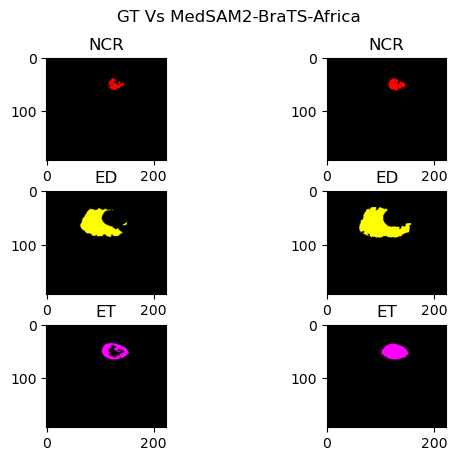

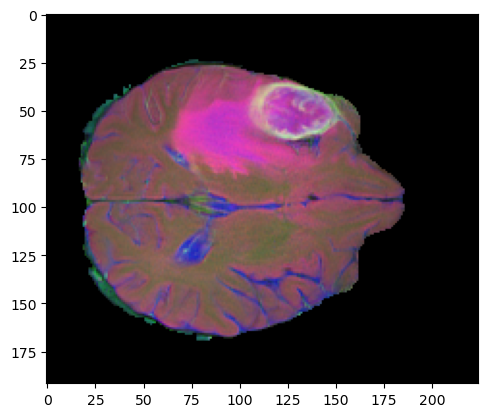

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[119.  94. 158. 121.]]
label.shape (3, 192, 224, 160)


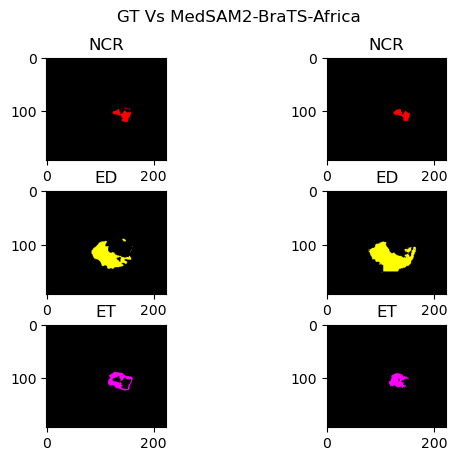

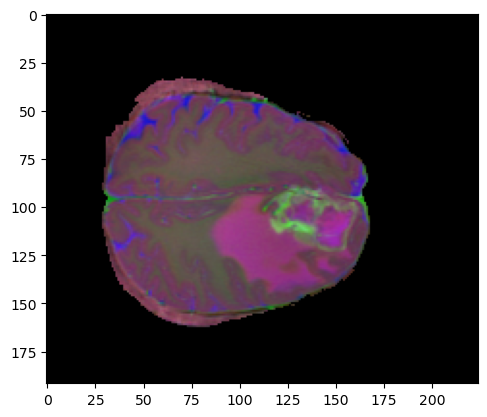

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[122.  55. 126.  59.]]
label.shape (3, 192, 224, 160)


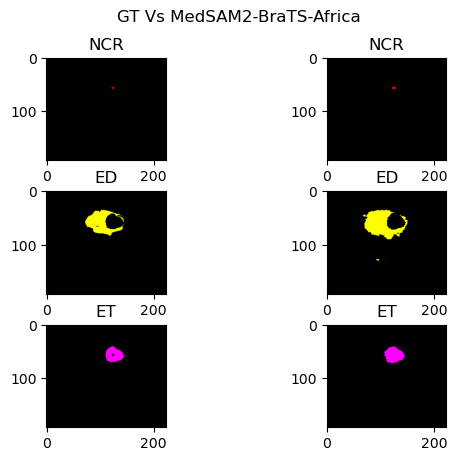

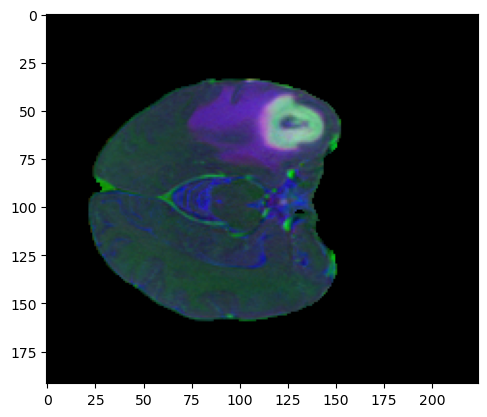

In [24]:
GLI_best_list = GLI_TTA_best.name.to_list()
GLI_best_dataset = MRIDataset(GLI_video_path, GLI_label_path, GLI_best_list)
visualize(GLI_best_dataset, "/scratch/radjoe/Projects/Experiments/SAMEXP/logs/decoder_only_adapter_example_tta_africa/logs/BraTS_GLI", 'GT Vs MedSAM2-BraTS-Africa', GLI_video_path)

### SSA BEST

[[ 94. 116. 101. 125.]]


FileNotFoundError: [Errno 2] No such file or directory: '/scratch/radjoe/Projects/Experiments/SAMEXP/logs/decoder_only_adapter_example_tta_gli/logs/BraTS_GLI/BraTS-SSA-00002-000.npy'

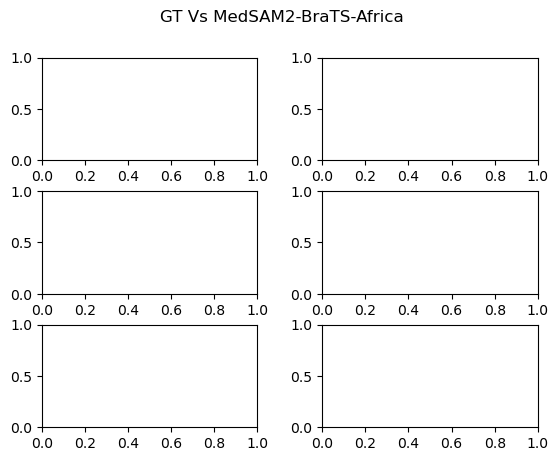

In [29]:
SSA_best_list = SSA_best.name.to_list()
SSA_best_dataset = MRIDataset(SSA_video_path, SSA_label_path, SSA_best_list)
visualize(SSA_best_dataset, "/scratch/radjoe/Projects/Experiments/SAMEXP/logs/decoder_only_adapter_example_tta_gli/logs/BraTS_GLI", 'GT Vs MedSAM2-BraTS-Africa', SSA_video_path)

### GLI Worst

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[110.  48. 167.  80.]]
label.shape (3, 192, 224, 160)


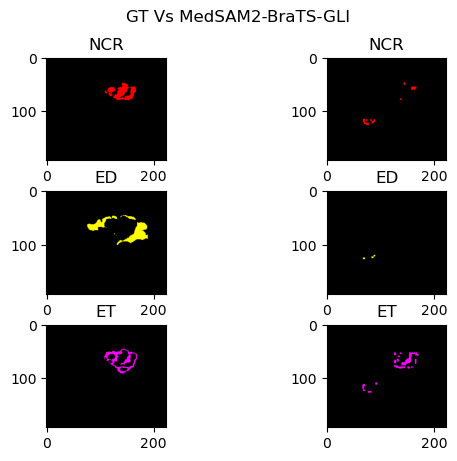

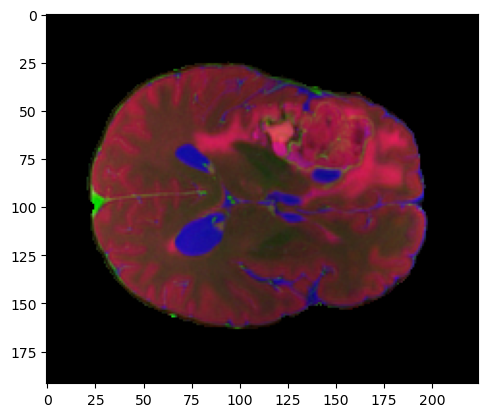

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[111. 116. 131. 131.]]
label.shape (3, 192, 224, 160)


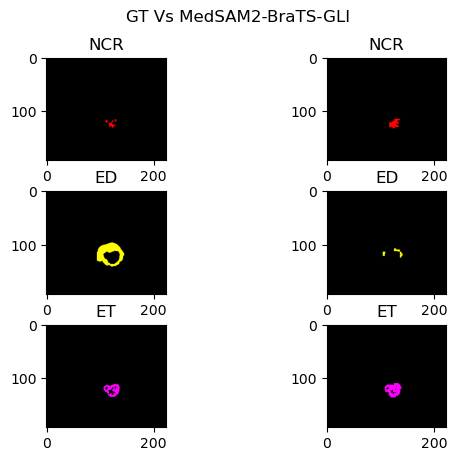

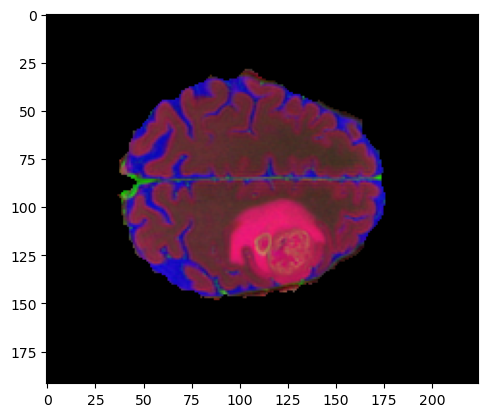

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[ 84.  90. 108. 103.]]
label.shape (3, 192, 224, 160)


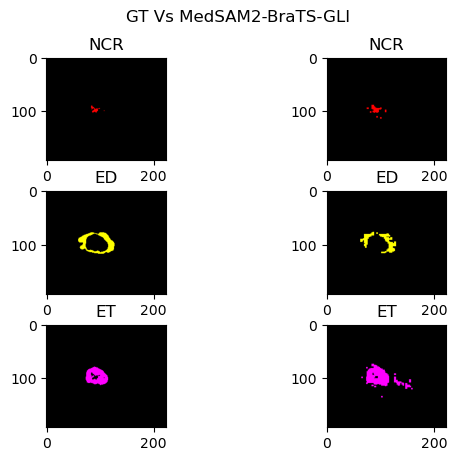

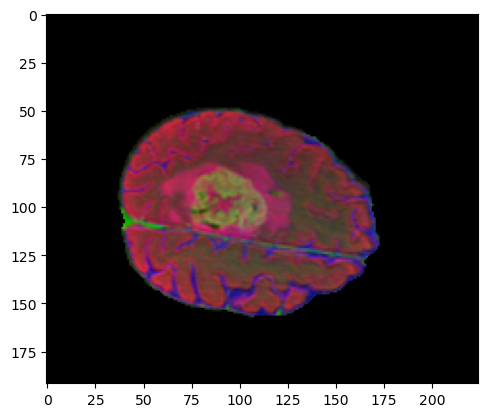

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[ 74. 114.  98. 132.]]
label.shape (3, 192, 224, 160)


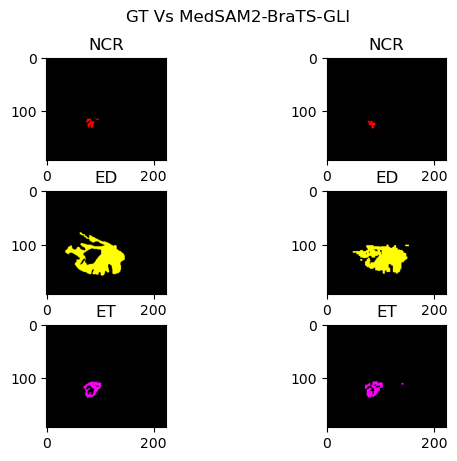

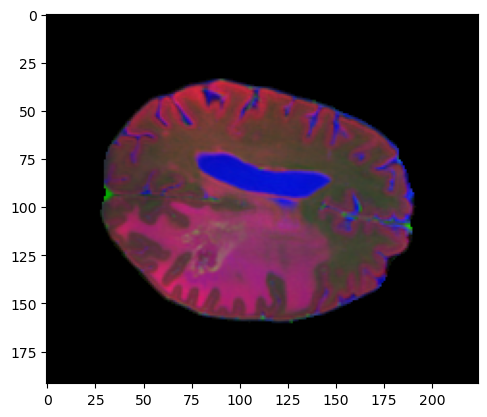

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[ 63. 140.  70. 146.]]
label.shape (3, 192, 224, 160)


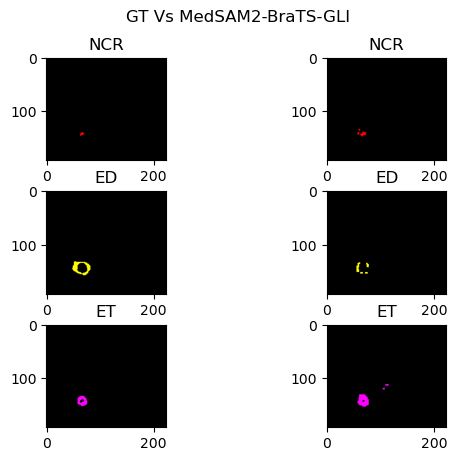

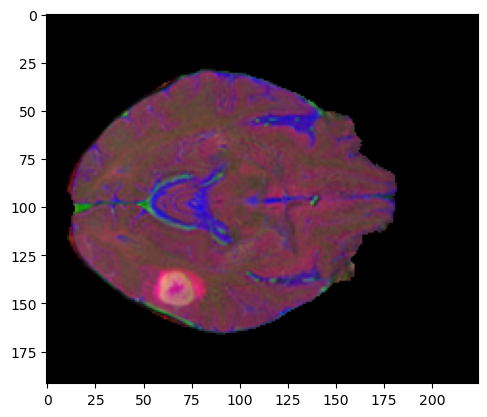

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[ 69. 108.  78. 116.]]
label.shape (3, 192, 224, 160)


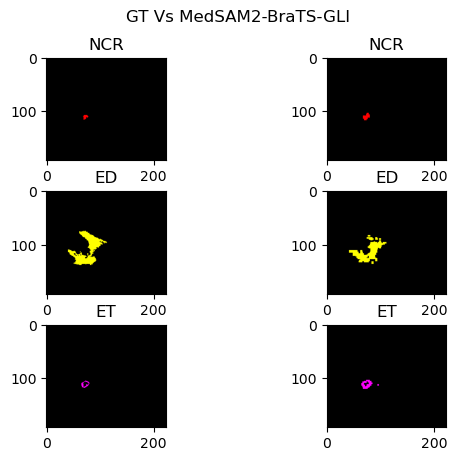

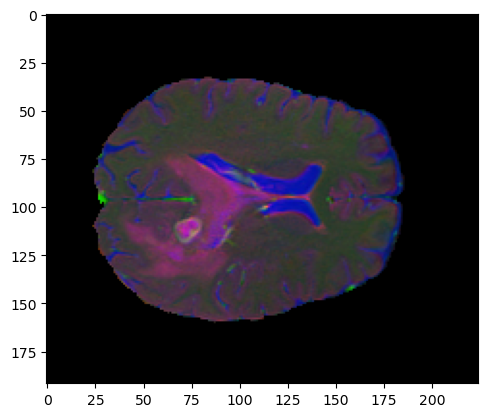

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[76. 71. 85. 81.]]
label.shape (3, 192, 224, 160)


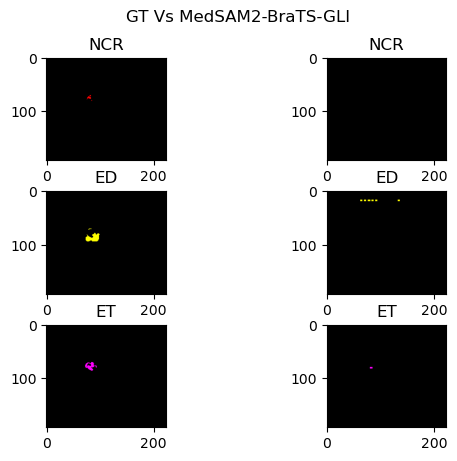

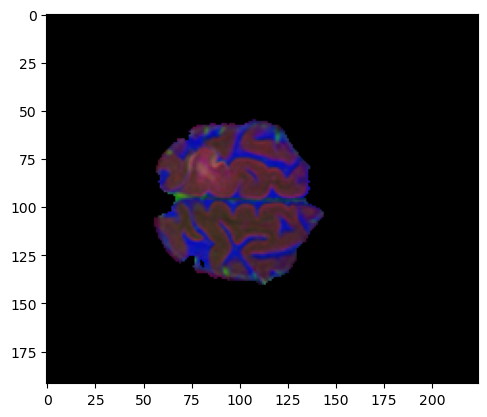

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[ 81. 101. 127. 146.]]
label.shape (3, 192, 224, 160)


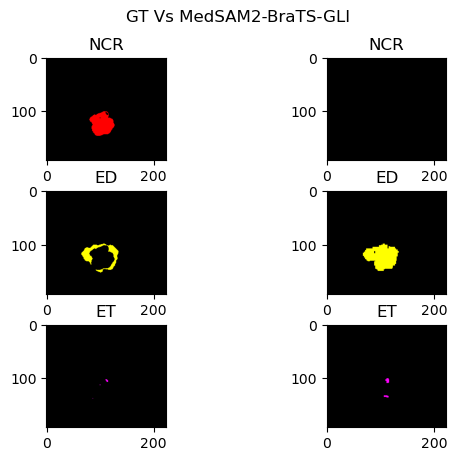

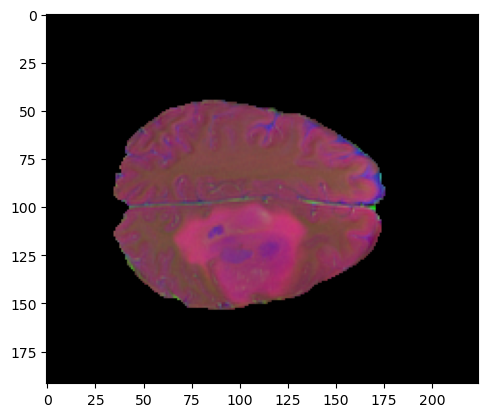

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[ 69.  33. 134.  84.]]
label.shape (3, 192, 224, 160)


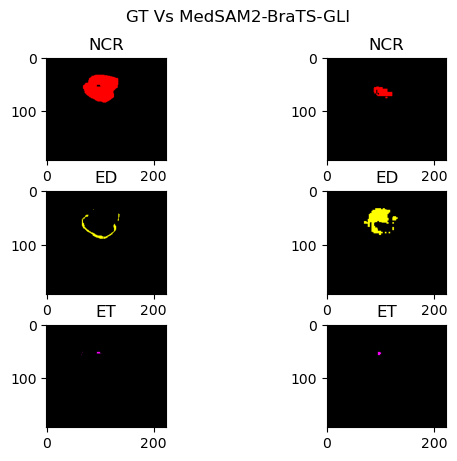

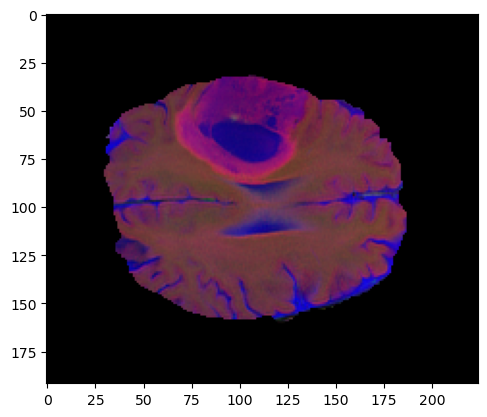

In [ ]:
GLI_worst_list = GLI_worst.name.to_list()
GLI_worst_dataset = MRIDataset(GLI_video_path, GLI_label_path, GLI_worst_list)
visualize(GLI_worst_dataset, GLI_pred_path, 'GT Vs MedSAM2-BraTS-GLI', GLI_video_path)

### SSA Worst

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[116.  88. 181. 132.]]
label.shape (3, 192, 224, 160)


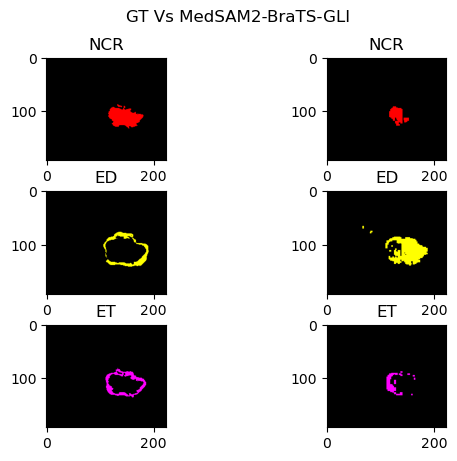

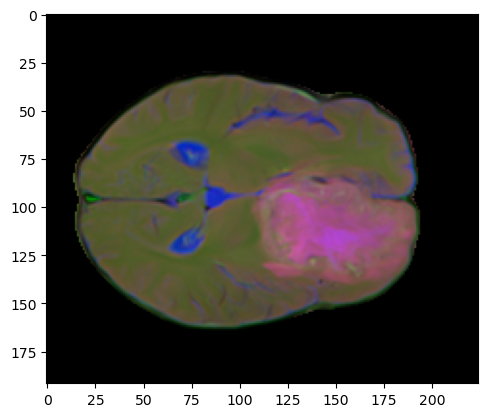

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[ 54.  77. 102. 125.]]
label.shape (3, 192, 224, 160)


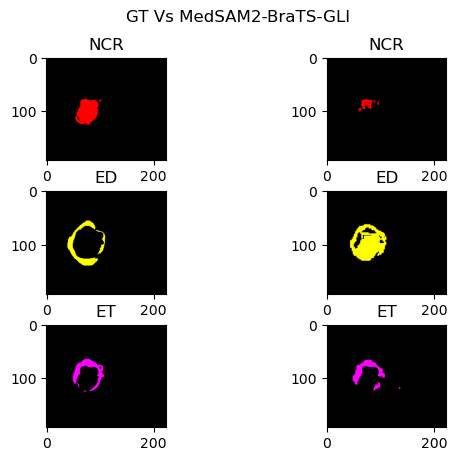

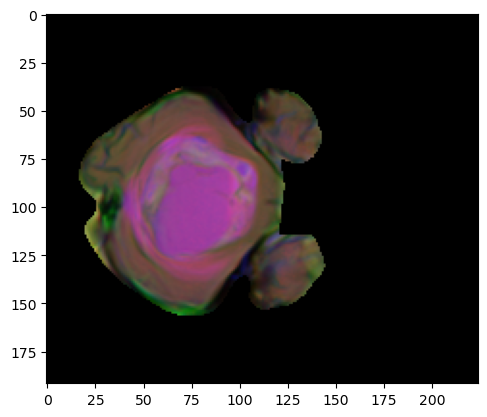

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[ 43. 115.  63. 125.]]
label.shape (3, 192, 224, 160)


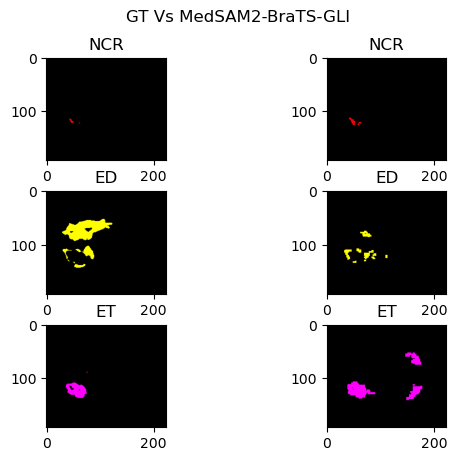

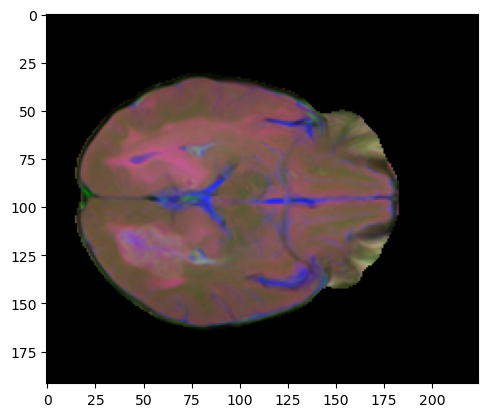

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[82. 94. 86. 99.]]
label.shape (3, 192, 224, 160)


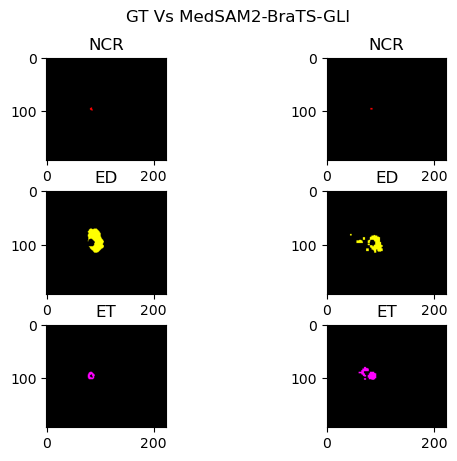

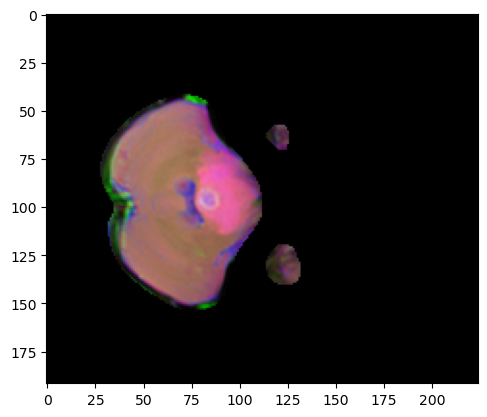

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[90. 90. 91. 92.]]
label.shape (3, 192, 224, 160)


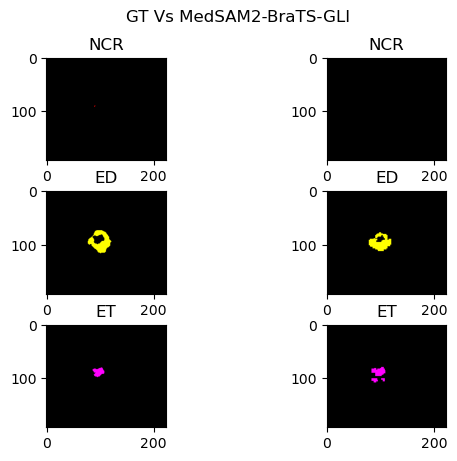

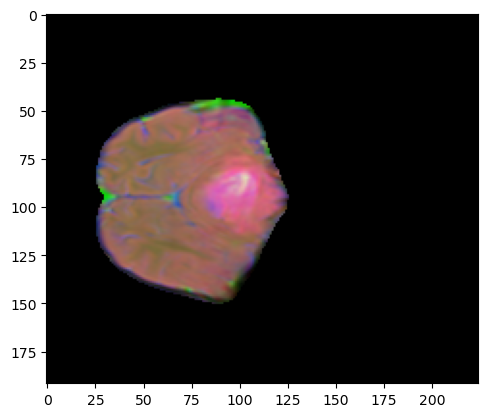

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[104. 111. 117. 125.]]
label.shape (3, 192, 224, 160)


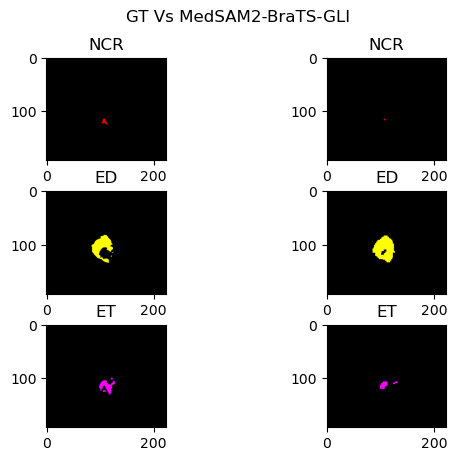

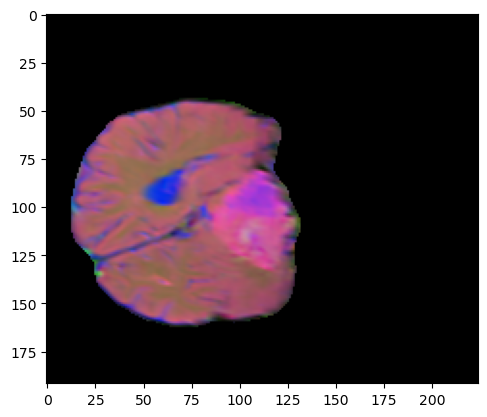

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[ 76.  89. 106. 103.]]
label.shape (3, 192, 224, 160)


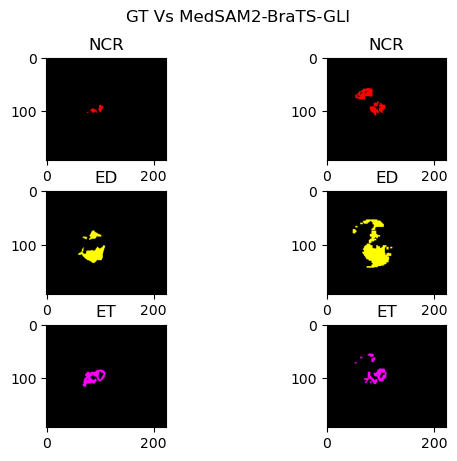

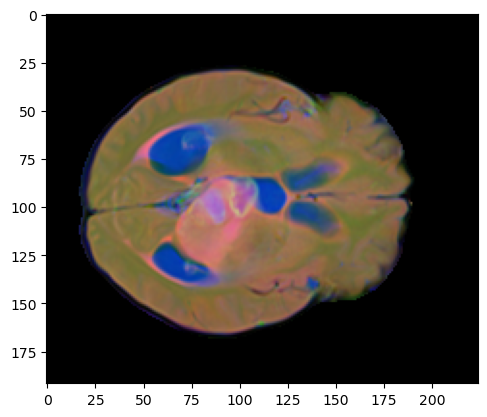

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[78. 74. 85. 82.]]
label.shape (3, 192, 224, 160)


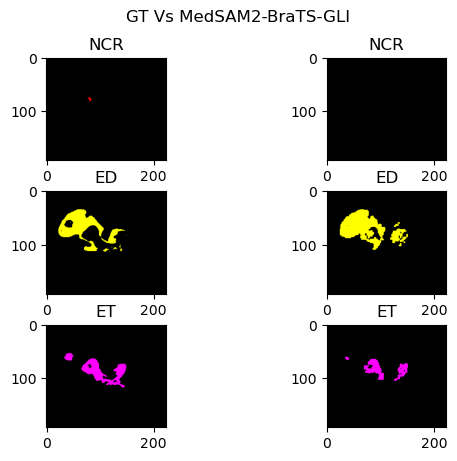

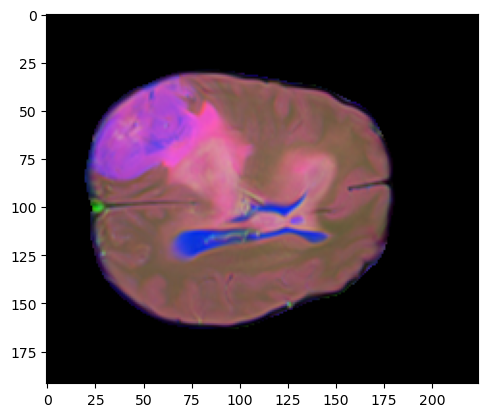

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[78. 89. 81. 94.]]
label.shape (3, 192, 224, 160)


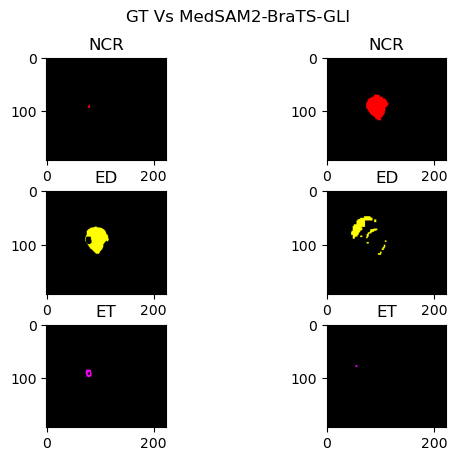

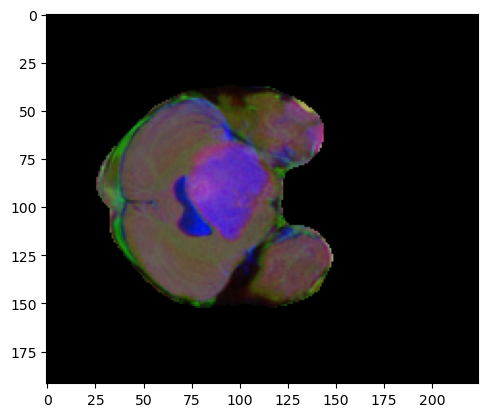

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[116. 125. 116. 126.]]
label.shape (3, 192, 224, 160)


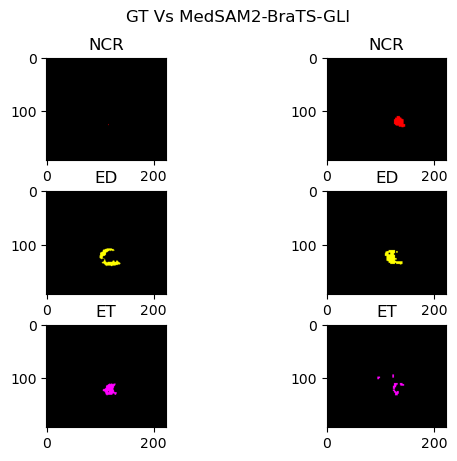

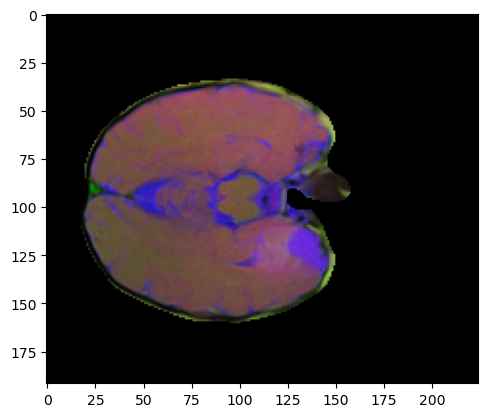

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[105.  41. 163. 122.]]
label.shape (3, 192, 224, 160)


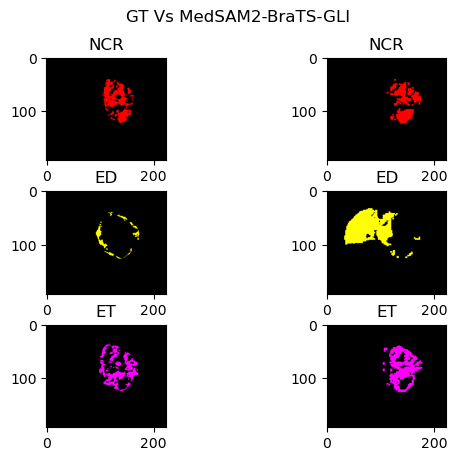

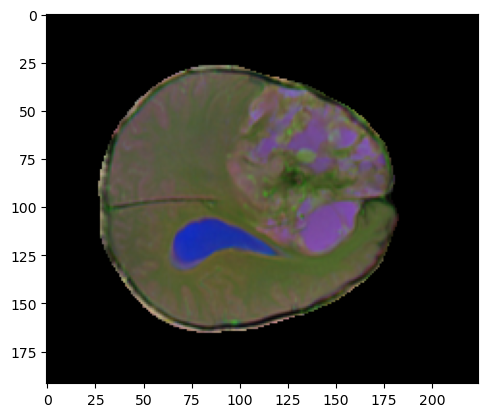

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[ 89.  39. 166. 105.]]
label.shape (3, 192, 224, 160)


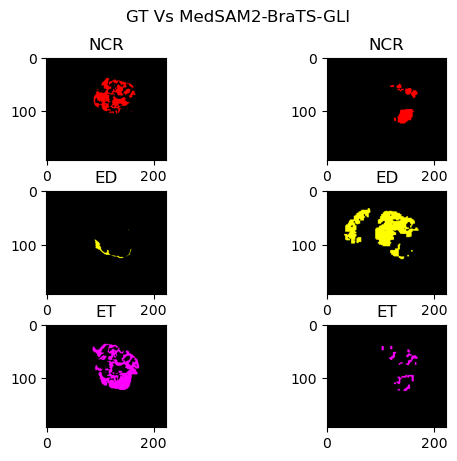

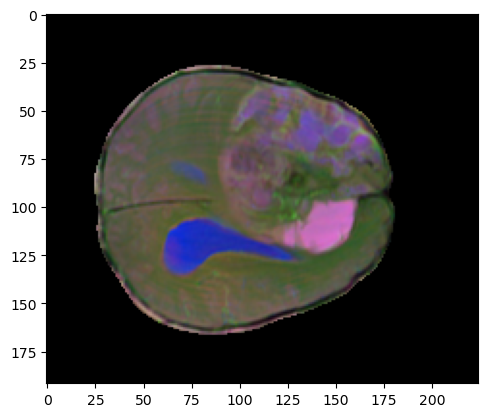

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


[[106.  91. 132. 104.]]
label.shape (3, 192, 224, 160)


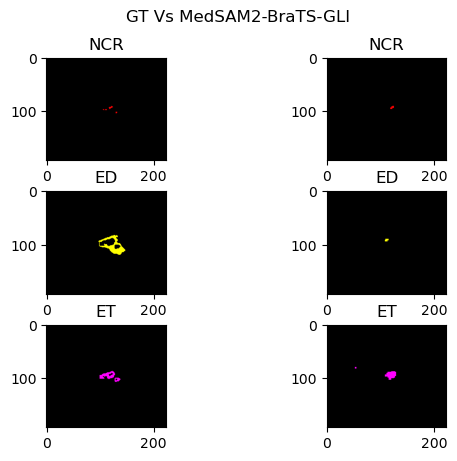

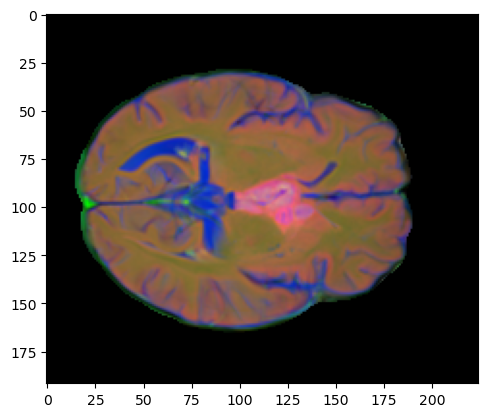

In [ ]:
SSA_worst_list = SSA_worst.name.to_list()
SSA_worst_dataset = MRIDataset(SSA_video_path, SSA_label_path, SSA_worst_list)
visualize(SSA_worst_dataset, SSA_pred_path, 'GT Vs MedSAM2-BraTS-GLI', SSA_video_path)

### GLI Mid

### SSA Mid

['BraTS-SSA-00092-000-stk.npy', 'BraTS-SSA-00120-000-stk.npy', 'BraTS-SSA-00037-000-stk.npy', 'BraTS-SSA-00041-000-stk.nii.gz', 'BraTS-SSA-00122-000-stk.npy', 'BraTS-SSA-00028-000-stk.npy', 'BraTS-SSA-00011-000-stk.npy', 'BraTS-SSA-00213-000-stk.nii.gz', 'BraTS-SSA-00146-000-stk.npy', 'BraTS-SSA-00015-000-stk.npy', 'BraTS-SSA-00074-000-stk.nii.gz', 'BraTS-SSA-00093-000-stk.npy', 'BraTS-SSA-00115-000-stk.nii.gz', 'BraTS-SSA-00026-000-stk.nii.gz', 'BraTS-SSA-00152-000-stk.npy', 'BraTS-SSA-00144-000-stk.npy', 'BraTS-SSA-00202-000-stk.nii.gz', 'BraTS-SSA-00044-000-stk.npy', 'BraTS-SSA-00056-000-stk.nii.gz', 'BraTS-SSA-00119-000-stk.nii.gz', 'BraTS-SSA-00015-000-stk.nii.gz', 'BraTS-SSA-00044-000-stk.nii.gz', 'BraTS-SSA-00080-000-stk.nii.gz', 'BraTS-SSA-00047-000-stk.npy', 'BraTS-SSA-00078-000-stk.nii.gz', 'BraTS-SSA-00127-000-stk.npy', 'BraTS-SSA-00110-000-stk.nii.gz', 'BraTS-SSA-00150-000-stk.npy', 'BraTS-SSA-00046-000-stk.nii.gz', 'BraTS-SSA-00223-000-stk.nii.gz', 'BraTS-SSA-00049-000-stk

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


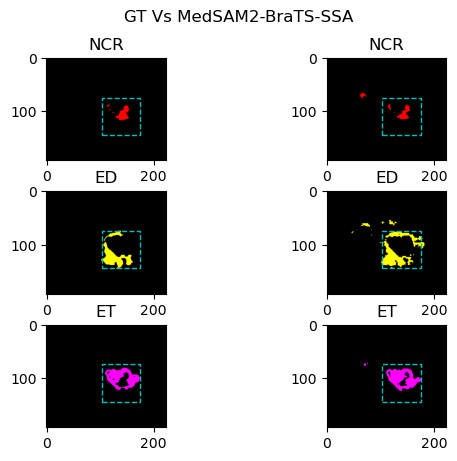

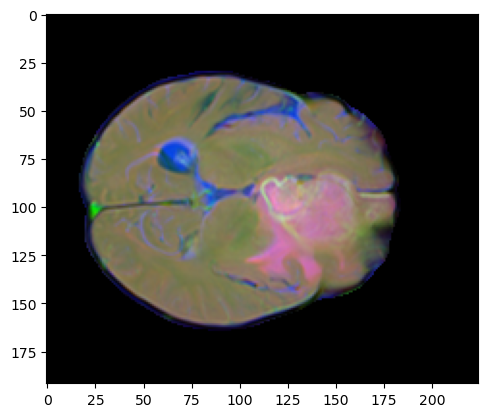

The original shape of label: torch.Size([3, 192, 224, 160])
The shape of label: tensor([0., 1.])
label counts: tensor([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    4,   23,   59,  137,  209,  291,  384,
         499,  627,  754,  874, 1077, 1464, 1835, 2151, 2350, 2528, 2721, 2921,
        3111, 3439, 3610, 3718, 3918, 4070, 4202, 4330, 4429, 4518, 4609, 4736,
        4890, 5015, 5124, 5232, 5301, 5357, 5411, 5393, 5467, 5455, 5494, 5491,
        5516, 5550, 5564, 5551, 5544, 5550, 5581, 5590, 5599, 5594, 5636, 5651,
        5674, 5683, 5661, 5602, 5527, 5410, 5246, 5085, 4943, 4823, 4714, 4557,
        4409, 4277, 4131, 3963, 3791, 3598, 3405, 3182, 2962, 2774, 2561, 2321,
        2

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


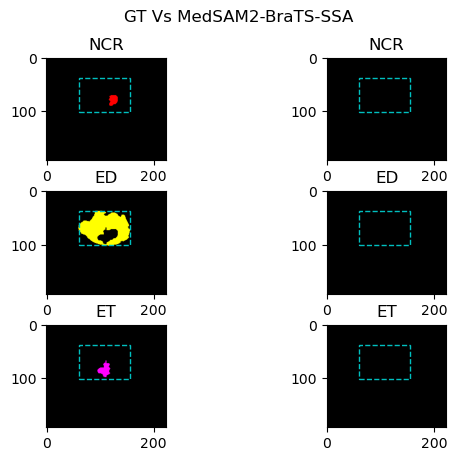

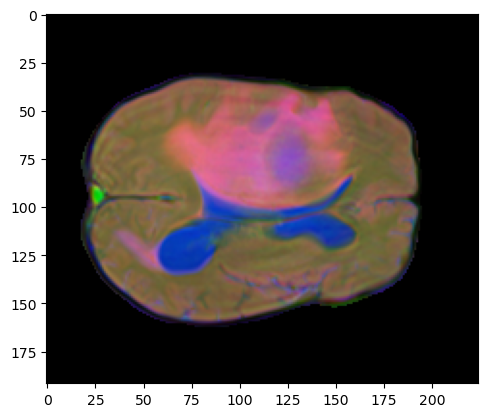

The original shape of label: torch.Size([3, 192, 224, 160])
The shape of label: tensor([0., 1.])
label counts: tensor([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,   14,   27,   51,   77,  151,  197,  238,  281,  412,
         636,  827, 1136, 1172, 1337, 1684, 2053, 2148, 2402, 2630, 2785, 2929,
        3124, 3396, 3605, 3791, 3910, 3974, 4059, 4240, 4351, 4395, 4444, 4490,
        4547, 4610, 4656, 4696, 4717, 4747, 4775, 4787, 4807, 4811, 4809, 4768,
        4698, 4636, 4633, 4614, 4547, 4457, 4346, 4163, 3977, 3820, 3699, 3602,
        3484, 3303, 3142, 2968, 2783, 2571, 2388, 2248, 2097, 1911, 1700, 1418,
        1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


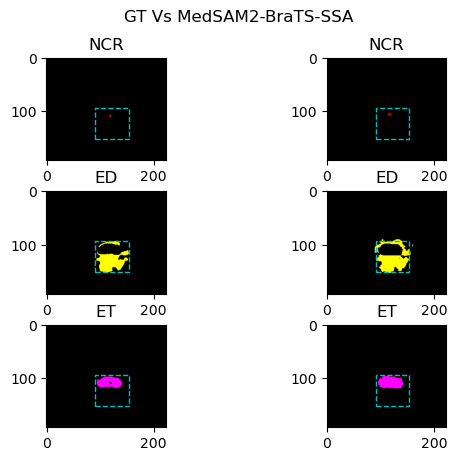

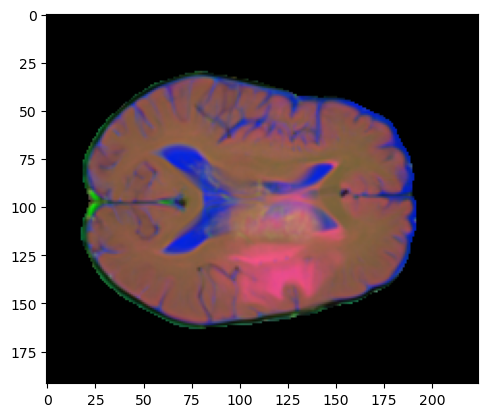

The original shape of label: torch.Size([3, 192, 224, 160])
The shape of label: tensor([0., 1.])
label counts: tensor([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           3,   30,   77,  143,  209,  332,  433,  530,  635,  759,  841,  951,
        1097, 1233, 1366, 1597, 1845, 2181, 2571, 2798, 2983, 3159, 3401, 3617,
        3854, 4048, 4170, 4235, 4284, 4357, 4436, 4510, 4561, 4594, 4606, 4628,
        4630, 4613, 4602, 4558, 4516, 4489, 4432, 4407, 4348, 4291, 4146, 4047,
        3915, 3797, 3666, 3555, 3455, 3326, 3227, 3057, 2827, 2727, 2640, 2562,
        2467, 2350, 2191, 2026, 1819, 1629, 1400, 1272, 1157, 1051,  875,  599,
         532,  474,  414,  347,  239,  230,  153,  137,  123,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
         

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


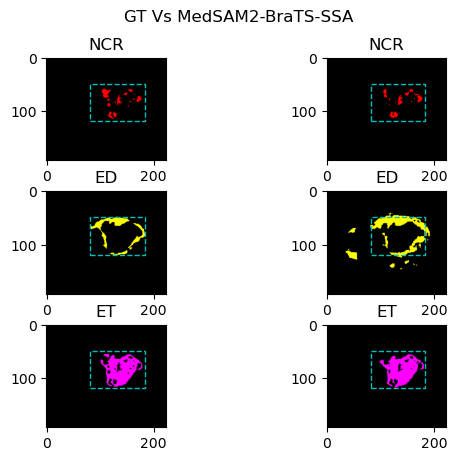

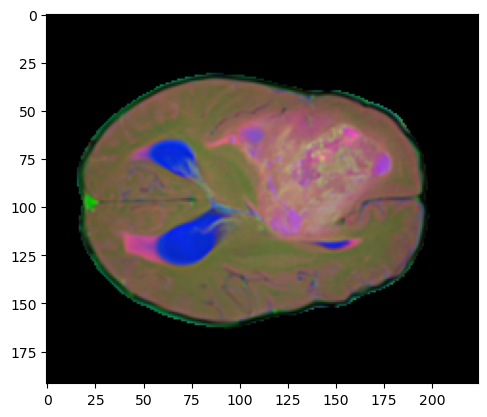

The original shape of label: torch.Size([3, 192, 224, 160])
The shape of label: tensor([0., 1.])
label counts: tensor([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,  489,  432,  442,  463,  762,  772, 1013,  979, 1226, 1202,
        1300, 1064, 1340, 1471, 1434, 1581, 1633, 1794, 1852, 1910, 2061, 2121,
        2491, 2747, 3042, 3121, 3281, 3536, 3658, 3989, 4091, 4357, 4315, 4431,
        4537, 4615, 4680, 4757, 4837, 4909, 4981, 5109, 5159, 5178, 5200, 5230,
        5267, 5265, 5235, 5190, 5143, 5066, 4980, 4881, 4751, 4650, 4565, 4433,
        4316, 4171, 4085, 4017, 3920, 3797, 3665, 3557, 3433, 3268, 3024, 2757,
        2

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


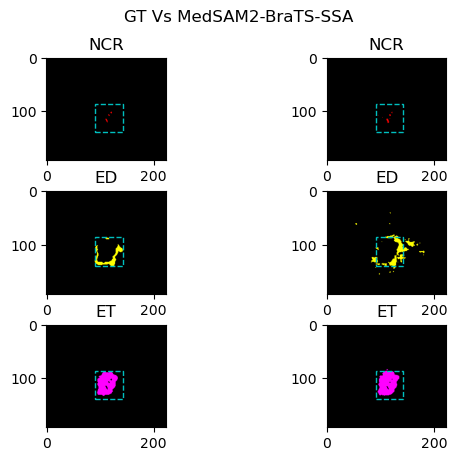

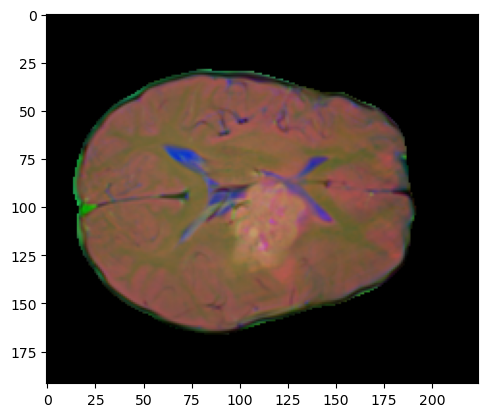

The original shape of label: torch.Size([3, 192, 224, 160])
The shape of label: tensor([0., 1.])
label counts: tensor([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,  116,
         193,  305,  329,  453,  599,  694,  833, 1237, 1715, 1974, 1885, 2004,
        2135, 2360, 2390, 2596, 2796, 3202, 3211, 3356, 3582, 3652, 3794, 4588,
        4500, 4912, 5078, 4927, 5153, 5050, 5109, 5013, 5141, 5158, 5165, 5242,
        5225, 4924, 4961, 4962, 4977, 4920, 4896, 4879, 4873, 4745, 4716, 4855,
        4804, 4793, 4810, 4674, 4706, 4778, 4568, 4379, 4290, 3857, 3716, 3582,
        3485, 3409, 3308, 3235, 3151, 2997, 2801, 2623, 2483, 2384, 2262, 2092,
        1933, 1725, 1477, 1297, 1161, 1016,  939,  855,  682,  490,  323,  138,
         

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


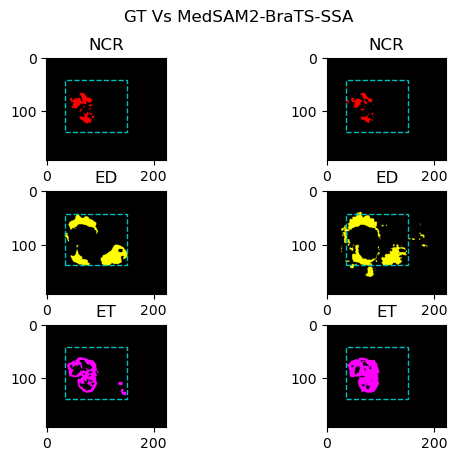

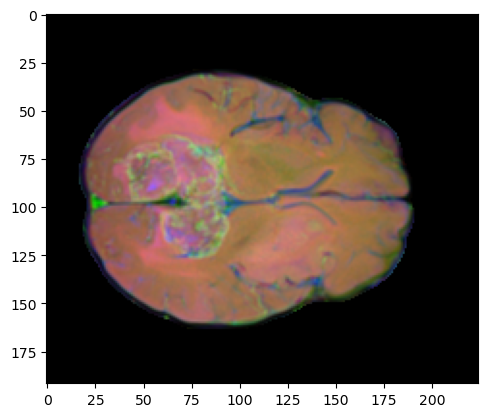

The original shape of label: torch.Size([3, 192, 224, 160])
The shape of label: tensor([0., 1.])
label counts: tensor([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,   10,   24,   37,   59,   94,  122,  158,  213,  256,
         289,  311,  335,  360,  396,  431,  467,  507,  539,  577,  606,  643,
         697,  749,  822, 1000, 1149, 1275, 1554, 1812, 2062, 2277, 2434, 2571,
        2702, 2805, 2921, 3081, 3279, 3427, 3590, 3768, 3911, 3963, 3997, 4035,
        4103, 4159, 4192, 4212, 4295, 4380, 4418, 4563, 4591, 4561, 4550, 4556,
        4480, 4404, 4339, 4255, 4154, 3995, 3826, 3747, 3438, 3280, 3089, 2903,
        2854, 2566, 2505, 2436, 2396, 2397, 2401, 2375, 2285, 2190, 2054, 1939,
        1806, 1645, 1471, 1305, 1092,  873,  670,  504,  328,  175,   68,   15,
         

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


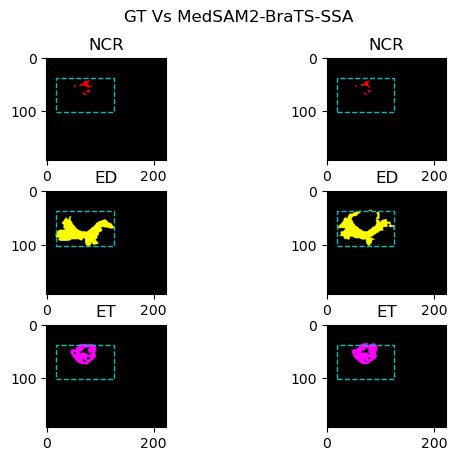

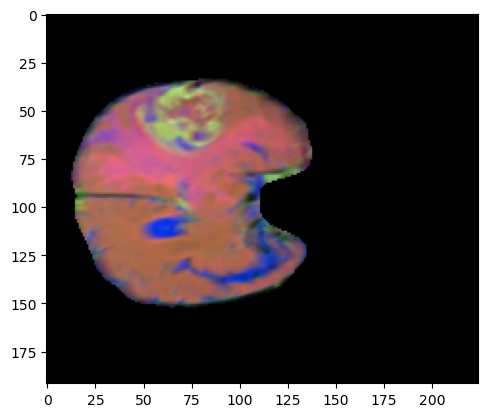

The original shape of label: torch.Size([3, 192, 224, 160])
The shape of label: tensor([0., 1.])
label counts: tensor([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,  141,  346,  453,  558,  680,  931, 1086, 1536, 1933,
        2425, 2634, 2948, 3179, 3439, 3690, 3847, 3977, 4214, 4314, 4424, 4473,
        4550, 4647, 4642, 4528, 4568, 4720, 4837, 4889, 4957, 5003, 5053, 5175,
        5097, 5143, 5111, 5214, 5222, 5269, 5274, 5200, 5120, 5148, 4967, 4725,
        4667, 4713, 4830, 4568, 4344, 4281, 4182, 4088, 3955, 3754, 3519, 3353,
        3207, 3039, 2853, 2680, 2500, 2335, 2150, 1994, 1871, 1761, 1660, 1518,
        1261, 1048,  886,  812,  759,  712,  657,  570,  465,  300,  162,   41,
         

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


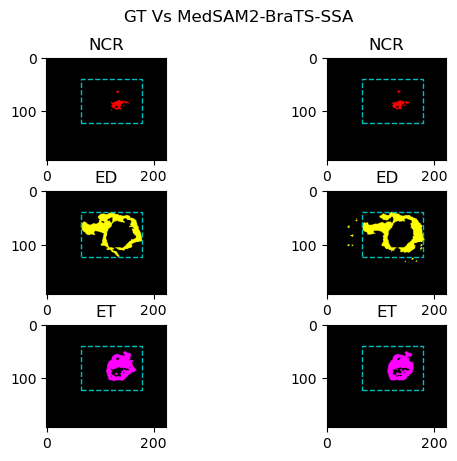

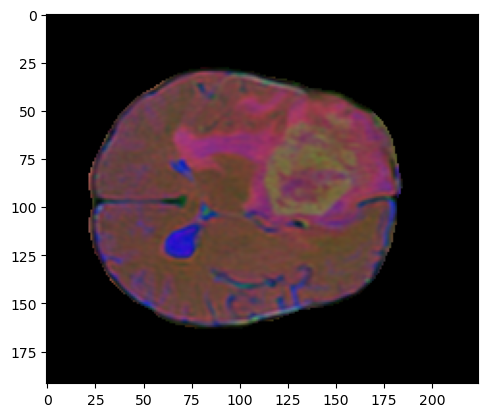

In [ ]:
SSA_mid_list = SSA_mid.name.to_list()
SSA_mid_dataset = MRIDataset(SSA_video_path, SSA_label_path, SSA_mid_list)
visualize(SSA_mid_dataset, SSA_pred_path, 'GT Vs MedSAM2-BraTS-SSA', SSA_video_path)

In [ ]:
SSA_int = GLI_TTA_df[GLI_TTA_df['name'].isin(GLI_mid['name'])]


In [ ]:
SSA_int

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
2,BraTS-GLI-00090-001.npy,0.165428,0.486636,0.797497,6.708204,19.000000,5.000000,0.092133,0.332902,0.963629,0.809091,0.904192,0.680225
4,BraTS-GLI-00172-000.npy,0.301938,0.744250,0.665598,10.677078,8.602325,60.903194,0.181558,0.683546,0.984603,0.896065,0.816787,0.502720
6,BraTS-GLI-00203-000.npy,0.513585,0.583299,0.604492,6.899000,8.831760,55.783497,0.407230,0.499751,0.621325,0.695130,0.700391,0.588548
13,BraTS-GLI-00452-000.npy,0.782750,0.405585,0.811634,4.242640,21.023796,3.000000,0.663568,0.263872,0.961482,0.954118,0.876088,0.702196
21,BraTS-GLI-00599-000.npy,0.698838,0.336239,0.853052,5.385165,13.490738,4.000000,0.636245,0.216344,0.870348,0.775091,0.754210,0.836430
26,BraTS-GLI-00742-000.npy,0.376288,0.065953,0.393473,8.602325,33.120991,12.884099,0.377218,0.034365,0.277820,0.375364,0.815963,0.674087
30,BraTS-GLI-01127-000.npy,0.727753,0.334829,0.664924,8.544003,21.377558,77.560944,0.684727,0.348239,0.736760,0.776548,0.322414,0.605851
35,BraTS-GLI-01191-000.npy,0.002242,0.029703,0.207275,33.734257,39.623226,32.000000,0.001123,0.015095,0.119900,0.716667,0.921691,0.764111
40,BraTS-GLI-01323-000.npy,0.095968,0.431631,0.809087,11.045361,25.258661,9.000000,0.053785,0.656203,0.973847,0.444918,0.321578,0.692010


In [ ]:
TTA_pred_path ='/scratch-second/radjoe_data/one_box_prompt_res/E-Meeting/BraTS_GLI/'

['BraTS-GLI-00563-000-stk.npy', 'BraTS-GLI-00803-000-stk.npy', 'BraTS-GLI-01276-000-stk.npy', 'BraTS-GLI-00736-001-stk.npy', 'BraTS-GLI-00557-000-stk.npy', 'BraTS-GLI-01180-000-stk.npy', 'BraTS-GLI-01127-000-stk.npy', 'BraTS-GLI-01191-000-stk.npy', 'BraTS-GLI-00196-000-stk.npy', 'BraTS-GLI-00742-000-stk.npy', 'BraTS-GLI-00689-001-stk.npy', 'BraTS-GLI-00064-000-stk.npy', 'BraTS-GLI-01017-000-stk.npy', 'BraTS-GLI-00756-000-stk.npy', 'BraTS-GLI-00289-000-stk.npy', 'BraTS-GLI-00172-000-stk.npy', 'BraTS-GLI-00403-000-stk.npy', 'BraTS-GLI-00452-000-stk.npy', 'BraTS-GLI-00692-001-stk.npy', 'BraTS-GLI-01291-000-stk.npy', 'BraTS-GLI-00343-000-stk.npy', 'BraTS-GLI-01218-000-stk.npy', 'BraTS-GLI-01661-000-stk.npy', 'BraTS-GLI-01171-000-stk.npy', 'BraTS-GLI-01355-000-stk.npy', 'BraTS-GLI-00491-000-stk.npy', 'BraTS-GLI-00715-000-stk.npy', 'BraTS-GLI-00542-000-stk.npy', 'BraTS-GLI-00491-001-stk.npy', 'BraTS-GLI-01170-000-stk.npy', 'BraTS-GLI-01147-000-stk.npy', 'BraTS-GLI-00165-000-stk.npy', 'BraTS-

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


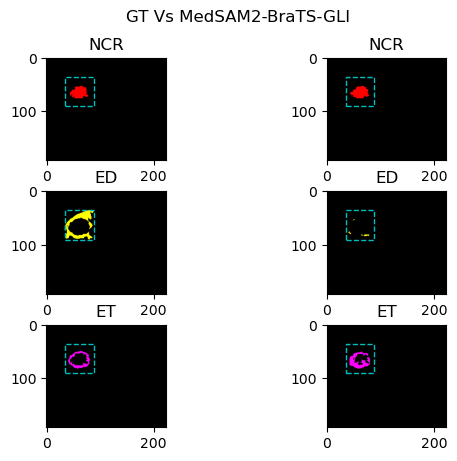

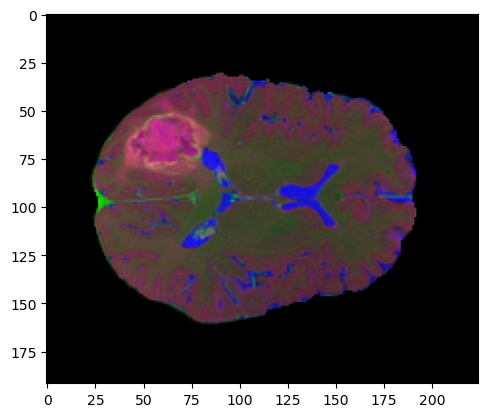

The original shape of label: torch.Size([3, 192, 224, 160])
The shape of label: tensor([0., 1.])
label counts: tensor([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    7,   19,   42,   67,   84,  109,  226,
         504,  814, 1003, 1271, 1499, 1620, 1784, 1960, 2103, 2204, 2295, 2371,
        2484, 2593, 2740, 2920, 3034, 3116, 3182, 3239, 3282, 3320, 3347, 3352,
        3342, 3325, 3305, 3300, 3389, 3507, 3619, 3647, 3674, 3697, 3736, 3777,
        3791, 3747, 3658, 3560, 3485, 3420, 3370, 3353, 3316, 3289, 3239, 3165,
        3103, 3011, 2841, 2647, 2443, 2301, 2207, 2131, 2008, 1874, 1723, 1608,
        1529, 1437, 1331, 1187, 1004,  700,  532,  426,  295,  118,   13,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
         

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


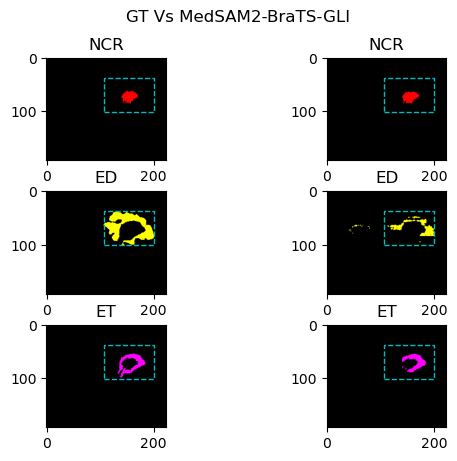

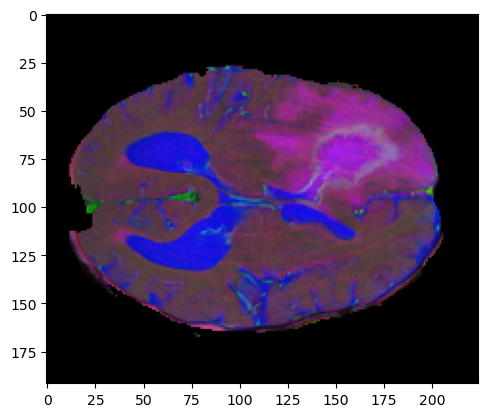

The original shape of label: torch.Size([3, 192, 224, 160])
The shape of label: tensor([0., 1.])
label counts: tensor([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,   25,   96,  243,  385,  484,  588,  692,  779,  869,
         933, 1002, 1088, 1206, 1304, 1381, 1590, 1738, 1887, 2019, 2181, 2268,
        2349, 2405, 2444, 2491, 2562, 2636, 2715, 2747, 2783, 2805, 2827, 2841,
        2851, 2847, 2832, 2810, 2785, 2750, 2669, 2561, 2445, 2332, 2224, 2071,
        1947, 1826, 1649, 1501, 1340, 1197, 1045,  899,  743,  563,  341,  128,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
         

FileNotFoundError: [Errno 2] No such file or directory: '/scratch-second/radjoe_data/one_box_prompt_res/E-Meeting/BraTS_GLI/BraTS-GLI-00043-000.npy'

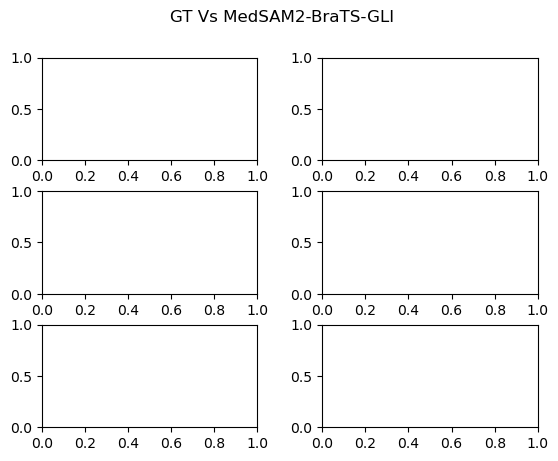

In [ ]:
SSA_mid_list = SSA_int.name.tail(0).to_list()
SSA_mid_dataset = MRIDataset(GLI_video_path, GLI_label_path, SSA_mid_list)
visualize(SSA_mid_dataset, TTA_pred_path, 'GT Vs MedSAM2-BraTS-GLI', GLI_video_path)

## T-Tests and Significance Tests

In [ ]:
apply_test(_EXP_df, _TTA_df, mannwhitneyu)

'\n    Results for NCR dice MannwhitneyuResult(statistic=1881.5, pvalue=0.06805394103183841) \n\n    Results for ET dice MannwhitneyuResult(statistic=2258.0, pvalue=5.922208203387131e-05) \n\n    Results for ED dice MannwhitneyuResult(statistic=1815.0, pvalue=0.15055555218804895) \n\n\n    Results for NCR HD MannwhitneyuResult(statistic=1558.0, pvalue=0.9582249831175325) \n\n    Results for ET HD MannwhitneyuResult(statistic=1236.0, pvalue=0.054008124975436195) \n\n    Results for ED HD MannwhitneyuResult(statistic=1688.0, pvalue=0.4849155151355995) \n\n                '

## Single Instance Analysis

In [173]:
img_path = f'/scratch_net/ken/radjoe/BraTS_SSA/Test/images_UNN/BraTS-SSA-00002-000-stk.npy'
pred_path = f'/scratch/radjoe/Projects/Experiments/SAMEXP/results/TT_NA_SSA/boxes/BraTS-SSA-00152-000.npy'
label_path = f'/scratch_net/ken/radjoe/BraTS_SSA/Test/labels_UNN/BraTS-SSA-00152-000-lbl.npy'
before_path = f'/scratch/radjoe/Projects/Experiments/SAMEXP/logs/restart_tta_dice_e10_soft/logs/BraTS_GLI/BraTS-SSA-00002-000.npy'

In [174]:
img = np.load(img_path)
pred = np.load(pred_path)
label = np.load(label_path)
before = np.load(before_path)


In [175]:
all_pred = np.zeros(pred.shape[1:])
all_label = np.zeros(label.shape[1:])
all_before = np.zeros(before.shape[1:])

In [176]:
all_pred[pred[1] == 1] = 1
all_pred[pred[2] == 1] = 2
all_pred[pred[3] == 1] = 3

In [177]:
all_label[label[1] == 1] = 1
all_label[label[2] == 1] = 2
all_label[label[3] == 1] = 3

In [178]:
all_before[before[1] == 1] = 1
all_before[before[2] == 1] = 2
all_before[before[3] == 1] = 3

In [185]:
frame = 65

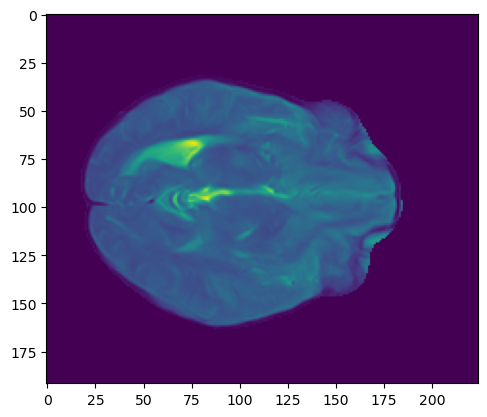

In [186]:
plt.imshow(img[3, :,:, frame])

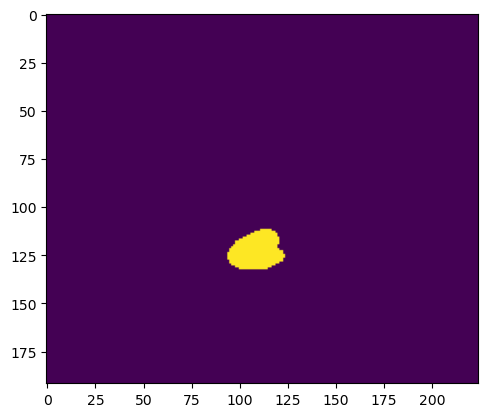

In [187]:
# plt.imshow(all_pred[:,:,frame])
# plt.show()
# plt.imshow(all_before[:,:,frame])
# plt.show()
plt.imshow(all_label[:,:,frame])
plt.show()

# plt.imshow(all_pred[:,frame,:])
# plt.show()
# plt.imshow(all_before[:,frame,:])
# plt.show()
# plt.imshow(all_label[:,frame,:])
# plt.show()

# plt.imshow(all_pred[frame,:,:])
# plt.show()
# plt.imshow(all_before[frame,:,:])
# plt.show()
# plt.imshow(all_label[frame,:,:])
# plt.show()

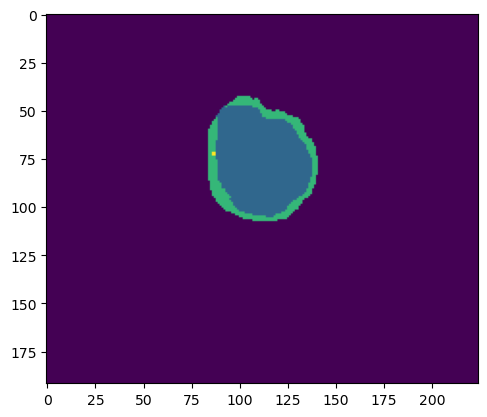

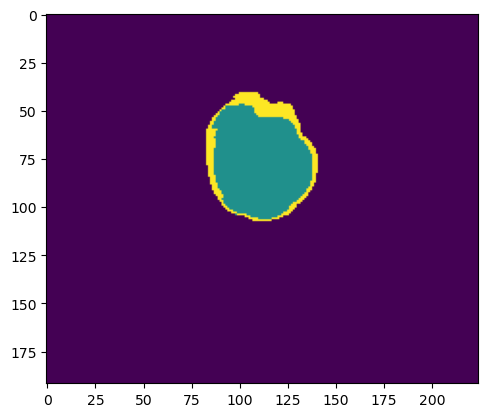

In [67]:
frame = 87
# plt.imshow(all_pred[:,:,frame])
# plt.show()
plt.imshow(all_before[:,:,frame])
plt.show()
plt.imshow(all_label[:,:,frame])
plt.show()

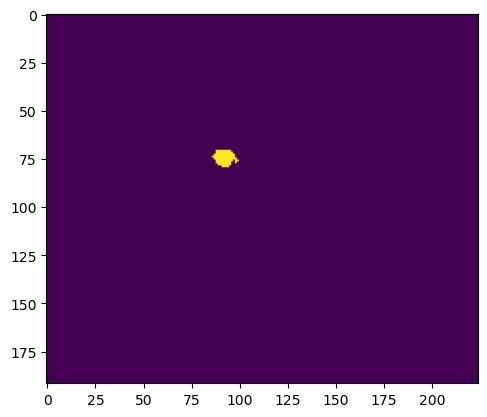

In [48]:
plt.imshow(pred[ 2, :,:,77])
plt.show()

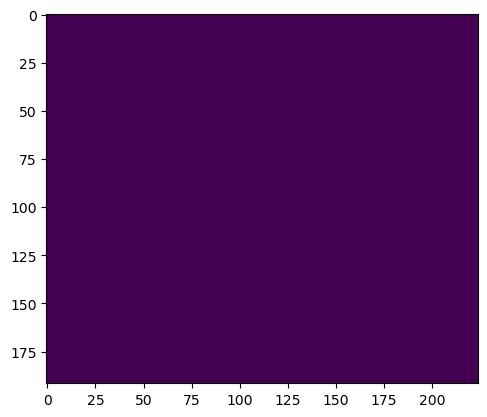

In [49]:
plt.imshow(label[3, :,:,77])
plt.show()

In [ ]:
pred_path = f'/scratch/radjoe/Projects/Experiments/SAMEXP/results/new/boxes/BraTS-GLI-01503-000.npy'
label_path = f'/scratch_net/ken/radjoe/BraTS/Tests/labels_UNN/BraTS-GLI-01503-000-lbl.npy'

In [ ]:
pred = np.load(pred_path)

label = np.load(label_path)

In [70]:
all_pred = np.zeros(pred.shape[1:])
all_label = np.zeros(label.shape[1:])

all_pred[pred[1] == 1] = 1
all_pred[pred[2] == 1] = 2
all_pred[pred[3] == 1] = 3

all_label[label[1] == 1] = 1
all_label[label[2] == 1] = 2
all_label[label[3] == 1] = 3

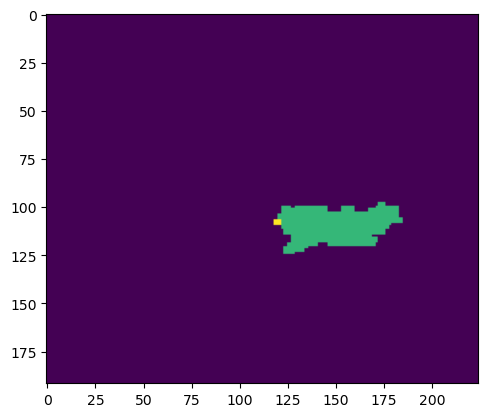

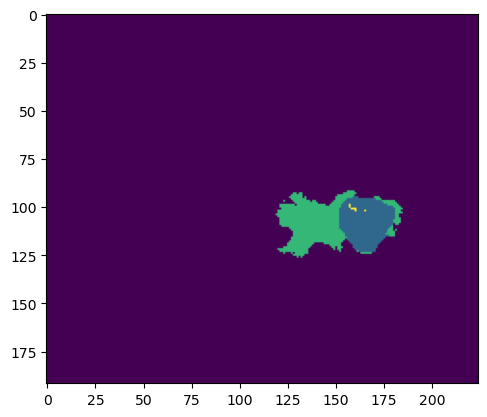

In [71]:
plt.imshow(all_pred[:,:,77])
plt.show()

plt.imshow(all_label[:,:,75])
plt.show()

In [110]:
pred_path = f'/scratch/radjoe/Projects/Experiments/SAMEXP/results/new_no_augs/boxes/BraTS-GLI-01503-000.npy'
label_path = f'/scratch_net/ken/radjoe/BraTS/Tests/labels_UNN/BraTS-GLI-01503-000-lbl.npy'

In [63]:
df = pd.read_csv('/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/results/F_GLI/boxes/SSA_boxes.csv')

In [64]:
df = clean_df(df, True, 'brats')
df.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,0.682645,0.492080,0.550135,24.985889,41.771687,26.904471,0.840390,0.621222,0.692425,0.617208,0.417496,0.535863
std,0.387311,0.248347,0.338863,43.112522,29.818280,39.970082,0.371304,0.243616,0.253786,0.378928,0.243641,0.386737
min,0.000000,0.083136,0.075806,2.236068,9.055386,2.236068,0.000000,0.158694,0.155743,0.000000,0.056321,0.040264
25%,0.547926,0.387927,0.286752,3.529141,21.310202,2.236068,0.952635,0.541474,0.679542,0.441575,0.292871,0.220806
50%,0.858315,0.441070,0.635425,6.403124,31.844900,4.358899,0.991359,0.707266,0.775976,0.754788,0.339388,0.512509
75%,0.935063,0.649618,0.832536,19.410096,58.259399,34.337532,0.993324,0.742696,0.809205,0.884805,0.577536,0.897562
max,0.954220,0.845262,0.901135,120.383553,92.362320,108.589127,0.999451,0.914254,0.937765,0.912906,0.785951,0.961535


In [94]:
df[(df['dice_ED'] < 0.4) & (df['dice_NCR'] < 0.4) & (df['dice_ET'] < 0.4)]

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
10,BraTS-GLI-00343-000.npy,0.184274,0.014212,0.251846,69.657013,131.857483,69.937820,0.924394,0.007402,0.705882,0.102337,0.177670,0.153264
31,BraTS-GLI-00736-001.npy,0.000220,0.399839,0.387422,79.432358,78.597710,93.370232,0.000576,0.286746,0.967445,0.000136,0.660234,0.242208
39,BraTS-GLI-01156-000.npy,0.143071,0.028854,0.078758,69.302956,58.895618,68.498177,0.085761,0.016121,0.266397,0.431269,0.137324,0.046210
45,BraTS-GLI-01218-000.npy,0.075386,0.042932,0.116775,42.731720,96.312515,41.825226,0.680352,0.030361,0.781121,0.039904,0.073269,0.063105
47,BraTS-GLI-01279-000.npy,0.000000,0.230679,0.057401,93.471382,58.583275,86.539299,0.000000,0.275358,0.196975,0.000000,0.198475,0.033595
54,BraTS-GLI-01459-000.npy,0.319106,0.000061,0.329529,48.030197,137.833954,74.222633,0.363340,0.000099,0.796210,0.284474,0.000044,0.207757
55,BraTS-GLI-01504-000.npy,0.013602,0.103386,0.020167,63.607391,58.086113,74.899933,0.007026,0.154759,0.347496,0.212870,0.077620,0.010385


In [62]:
df = pd.read_csv('/scratch/radjoe/Projects/Experiments/SAMEXP/logs/decoder_only_augs_70/logs/BraTS_GLI/SSA_boxes.csv')
df

,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0,BraTS-GLI-00000-000.npy,0.505056,0.022295,0.568371,5.385165,76.713753,4.123106,0.338303,0.474135,0.512725,0.995987,0.011416,0.637566
1,1,BraTS-GLI-01357-000.npy,0.824627,0.078837,0.440407,3.464102,89.861000,4.358899,0.705071,0.931961,0.637908,0.993007,0.041160,0.336289
2,2,BraTS-GLI-01361-000.npy,0.328862,0.093980,0.776851,13.453624,91.333954,10.198039,0.196959,0.786706,0.752869,0.995623,0.049975,0.802411
3,3,BraTS-GLI-01503-000.npy,0.000000,0.025498,0.000000,77.502838,108.231232,42.716507,0.000000,0.996665,0.000000,0.000000,0.012914,0.000000


In [ ]:
from torchvision.utils import save_image
import random
import torchvision.transforms.functional as F


eps: float = 1e-6
def renormalize(arr):
    foreground = arr[arr != 0]
    min_val, max_val = np.min(foreground), np.max(foreground)

    scaled = (arr - min_val) / (max_val - min_val + 1e-8)
    scaled[arr == 0] = 0 

    return scaled
def __init__(
        self,
        consistent_transform: bool,
        p: float = 0.5,
        ed_modalities=(2, 1),      # FLAIR, T2 (adjust to your ordering)
        et_modalities=(0,),        # T1ce
        ed_scale=(0.7, 0.9),
        et_scale=(0.7, 0.9),
        ed_gamma=(0.9, 1.1),
        et_gamma=(0.9, 1.1),
        
    ):
        self.consistent_transform = consistent_transform
        self.p = float(p)
        self.ed_modalities = tuple(ed_modalities)
        self.et_modalities = tuple(et_modalities)
        self.ed_scale = tuple(ed_scale)
        self.et_scale = tuple(et_scale)
        self.ed_gamma = tuple(ed_gamma)
        self.et_gamma = tuple(et_gamma)
        self.eps = float(eps)

    # @torch.no_grad()
def _sample_params(self):
        """Sample random (scale, gamma) for ED and ET."""
        ed_scale = random.uniform(*self.ed_scale)
        et_scale = random.uniform(*self.et_scale)
        ed_gamma = random.uniform(*self.ed_gamma)
        et_gamma = random.uniform(*self.et_gamma)
        return ed_scale, ed_gamma, et_scale, et_gamma

def _ensure_hw_mask(self, m):
        # Accept [H,W] or [1,H,W]; return [H,W] bool
        if m is None:
            return None
        if m.dim() == 3 and m.size(0) == 1:
            m = m[0]
        return m.bool()

    # @torch.no_grad()
def _apply_on_channel( ch, mask, scale, gamma):
        """
        ch: [H,W] float tensor (one modality)
        mask: [H,W] bool tensor
        """
        if mask is None or not mask.any():
            return ch

        # Per-channel min-max norm to [0,1] for stable gamma
        cmin = np.amin(ch, axis=(0, 1), keepdims=False)
        cmax = np.amax(ch, axis=(0, 1), keepdims=False)
        if (cmax - cmin) <= eps:
            return ch  # nearly constant channel; skip

        x = (ch - cmin) / (cmax - cmin + eps)    # [0,1]
        x_aug = scale * np.clip(x ** gamma, 0.0, 1.0)
        x_aug = x_aug * (cmax - cmin) + cmin          # back to original range

        # Blend only inside mask
        out = np.where(mask, x_aug, ch)
        return out
    
def compute_balancing_scales( x, ed_mask, et_mask, alpha=0.5, smin=0.7, smax=1.3, ref='mean'):
        """
        x: [C,H,W] (or [B,C,H,W] with B==1); float in [0,1] preferred
        ed_mask, et_mask: [H,W] bool
        Returns (s_ed, s_et) scalars.
        """
        # x = x.float()
        if x.ndim == 4:
            x = x[0]                     # make it [C,H,W]
        
        if ref == 'mean':
            x_ref = x.mean(axis=0)        # [H,W] average over channels
        elif isinstance(ref, int):        # pick a channel index
            x_ref = x[ref]
        else:
            x_ref = x.mean(axis=0)

        ed_mask = ed_mask > 0
        et_mask = et_mask > 0
        # (optional) squeeze masks like [1,H,W] -> [H,W]
        # if ed_mask.ndim == 3 and ed_mask.size(0) == 1: ed_mask = ed_mask.squeeze(0)
        # if et_mask.ndim == 3 and et_mask.size(0) == 1: et_mask = et_mask.squeeze(0)

        # means inside regions
        if ed_mask.any() and et_mask.any():
            me = x_ref[ed_mask].mean().item()
            mt = x_ref[et_mask].mean().item()
            if me > 1e-6 and mt > 1e-6:
                s_ed = (mt / me) ** alpha
                s_et = (me / mt) ** alpha
            else:
                s_ed = s_et = 1.0
        else:
            s_ed = s_et = 1.0

        s_ed = float(max(smin, min(s_ed, smax)))
        s_et = float(max(smin, min(s_et, smax)))
        return s_ed, s_et


def targeted_contrast(datapoint, label):
        datapoint = np.delete(datapoint, 1, axis=0)
        print(f'Datapoint shape after deletion: {datapoint.shape}')
        for i in range(datapoint.shape[0]):
            datapoint[i] = renormalize(datapoint[i])

        print(f'datapoint shape after renormalization: {datapoint.shape}, len(datapoint): {len(datapoint)}')
        for idx in range(datapoint.shape[3]):
            print(f'Processing frame {idx}')
            x = datapoint[:,:,:,idx]
            # print(f'info on x: {x.shape}')
            if idx > 75 and idx < 85:
                to_show = np.transpose(x, (1,2,0))

                plt.imshow(to_show)
                # plt.savefig(f"before_jup{idx}.png")
                plt.show()

            # print(f'length of list: {datapoint.frames[idx].objects[0]}')
            print(f'Length of mask list: {label.shape}' )
            mask = label[:, :,:,idx]

            if mask is None:
                print(f"Warning: No segmentation mask found for frame {idx}.")
                continue

            # boolean region masks from class labels
            ed_mask = mask[2]
            et_mask = mask[3]

            ed_modalities = [0, 2]      
            et_modalities = [1]
            # Apply ED reduction
            ed_scale, et_scale = compute_balancing_scales(x, ed_mask, et_mask)
            ed_gamma_range = (1.0, 1.5)
            et_gamma_range = (1.0, 1.8)
            ed_gamma = np.random.uniform(*ed_gamma_range)
            et_gamma = np.random.uniform(*et_gamma_range)
            print(f'ED Mask: {ed_mask.any()}, ET Mask: {et_mask.any()}, ed_mask shape: {ed_mask.shape}, et_mask shape: {et_mask.shape}, ed_scale: {ed_scale}, et_scale: {et_scale}')
            if ed_mask.any():
                for m in ed_modalities:
                    # if 0 <= m < x.size(0):
                        arr = _apply_on_channel(x[m], ed_mask, ed_scale, ed_gamma)
                        x[m] = arr.astype(x.dtype, copy=False)

            # Apply ET reduction
            if et_mask.any():
                for m in et_modalities:
                    # if 0 <= m < x.size(0):
                        x[m] = _apply_on_channel(x[m], et_mask, et_scale, et_gamma).astype(x.dtype, copy=False)
            # print(f'Saving....')
            # save_image(x.float()/255.0, f"after_{idx}.png")
            # print(f'Saved!')
            # back to PIL
            
            # a = 0.5  # 20% darker
            print(f'Before applying a: {x[ed_modalities].mean()}, {x[et_modalities].mean()}')

            # if idx > 75 and idx < 85:
            #     to_show = np.transpose(x, (1,2,0))

            #     plt.imshow(to_show)
            #     # plt.savefig(f"after_jup{idx}.png")
            #     plt.show()
            datapoint[:,:,:,idx] = x

        return datapoint


In [347]:
images_path = f'/scratch_net/ken/radjoe/BraTS/Tests/images_UNN/BraTS-GLI-01357-000-stk.npy'

In [348]:
pred = np.load(images_path)

In [349]:
pred.shape

(4, 192, 224, 160)

In [350]:
label_path = f'/scratch_net/ken/radjoe/BraTS/Tests/labels_UNN/BraTS-GLI-01357-000-lbl.npy'
label = np.load(label_path)

Datapoint shape after deletion: (3, 192, 224, 160)
datapoint shape after renormalization: (3, 192, 224, 160), len(datapoint): 3
Processing frame 0
Length of mask list: (4, 192, 224, 160)
ED Mask: False, ET Mask: False, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.0, et_scale: 1.0
Before applying a: 0.0, 0.0
Processing frame 1
Length of mask list: (4, 192, 224, 160)
ED Mask: False, ET Mask: False, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.0, et_scale: 1.0
Before applying a: 0.0, 0.0
Processing frame 2
Length of mask list: (4, 192, 224, 160)
ED Mask: False, ET Mask: False, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.0, et_scale: 1.0
Before applying a: 0.0, 0.0
Processing frame 3
Length of mask list: (4, 192, 224, 160)
ED Mask: False, ET Mask: False, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.0, et_scale: 1.0
Before applying a: 0.0, 0.0
Processing frame 4
Length of mask list: (4, 192, 224, 160)
ED Ma

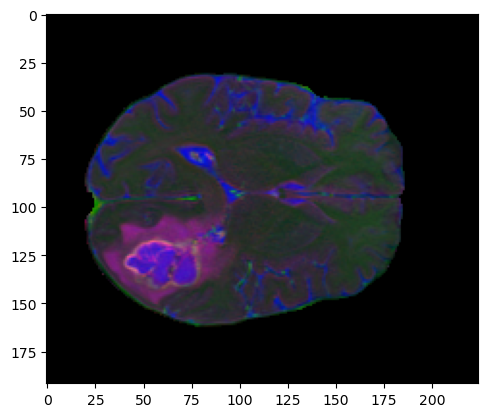

Length of mask list: (4, 192, 224, 160)
ED Mask: True, ET Mask: True, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.1517017256044693, et_scale: 0.8682803696201385
Before applying a: 0.09536298364400864, 0.07365895807743073


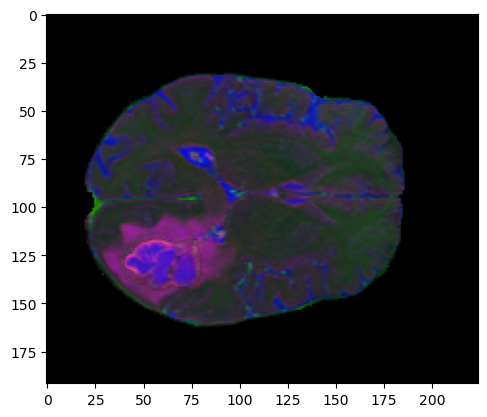

Processing frame 77


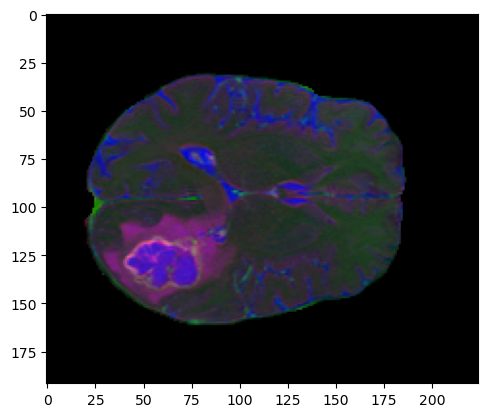

Length of mask list: (4, 192, 224, 160)
ED Mask: True, ET Mask: True, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.1575928093783785, et_scale: 0.863861620336943
Before applying a: 0.09243539720773697, 0.07432111352682114


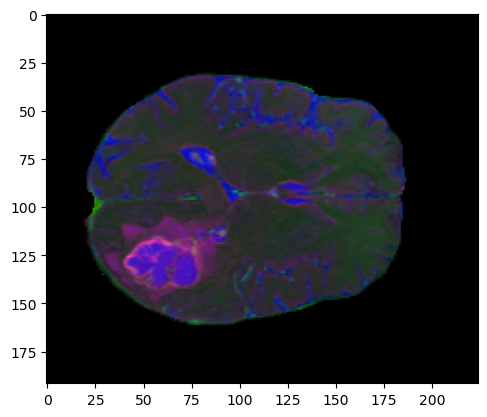

Processing frame 78


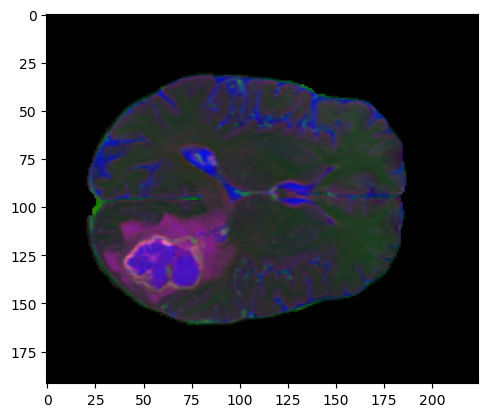

Length of mask list: (4, 192, 224, 160)
ED Mask: True, ET Mask: True, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.1581890934989438, et_scale: 0.8634168682930288
Before applying a: 0.09405847638845444, 0.07397393137216568


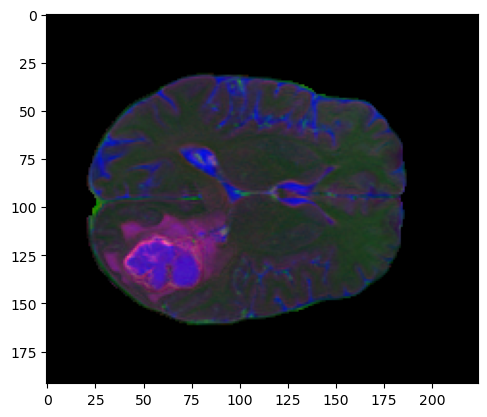

Processing frame 79


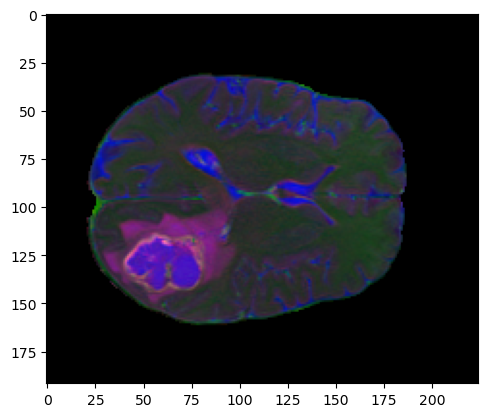

Length of mask list: (4, 192, 224, 160)
ED Mask: True, ET Mask: True, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.1747586574785451, et_scale: 0.8512386724149451
Before applying a: 0.09624732285737991, 0.07408095896244049


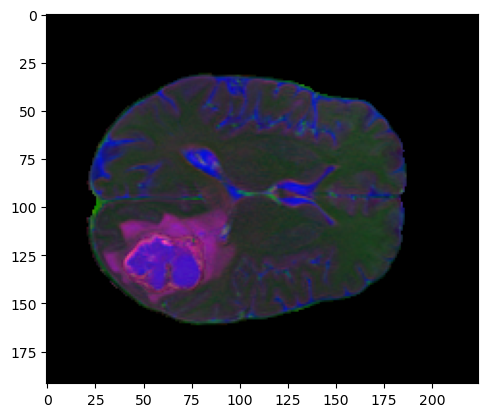

Processing frame 80


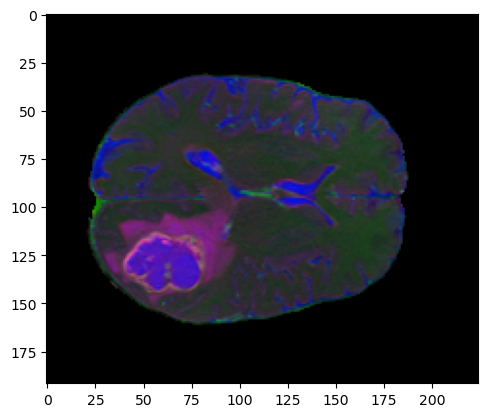

Length of mask list: (4, 192, 224, 160)
ED Mask: True, ET Mask: True, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.1604717530515891, et_scale: 0.8617185186717292
Before applying a: 0.09563019126653671, 0.07430260628461838


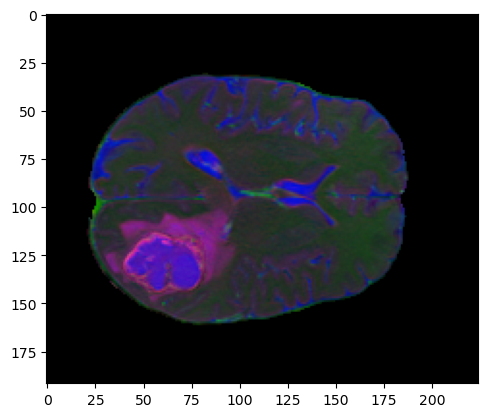

Processing frame 81


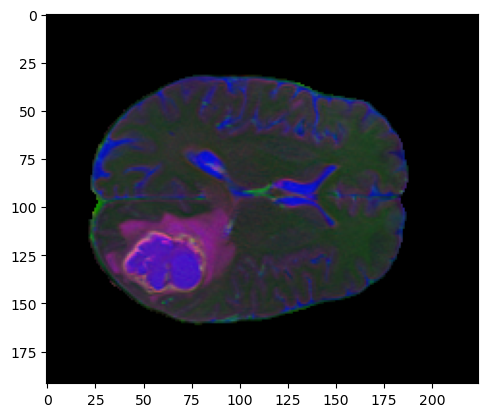

Length of mask list: (4, 192, 224, 160)
ED Mask: True, ET Mask: True, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.1575711472958135, et_scale: 0.8638777861180169
Before applying a: 0.09447405487298965, 0.07419705390930176


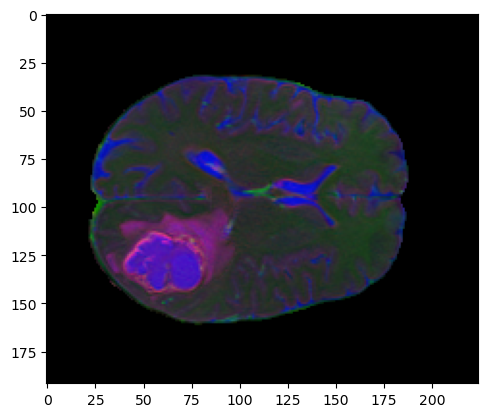

Processing frame 82


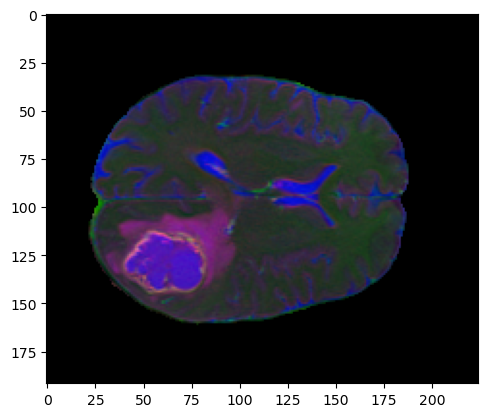

Length of mask list: (4, 192, 224, 160)
ED Mask: True, ET Mask: True, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.161008467055926, et_scale: 0.8613201612007106
Before applying a: 0.09623046964406967, 0.07357927411794662


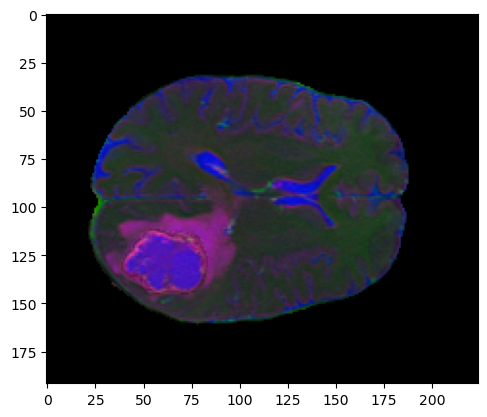

Processing frame 83


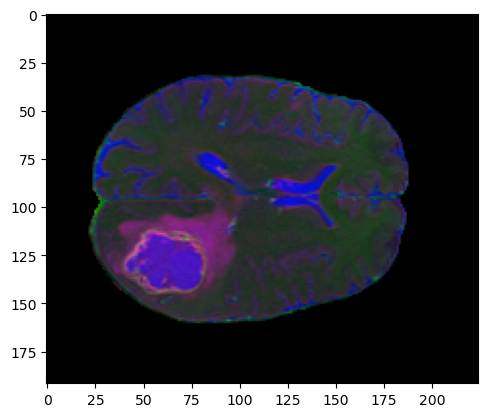

Length of mask list: (4, 192, 224, 160)
ED Mask: True, ET Mask: True, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.1533741280421175, et_scale: 0.8670213555921581
Before applying a: 0.0951719880104065, 0.07414354383945465


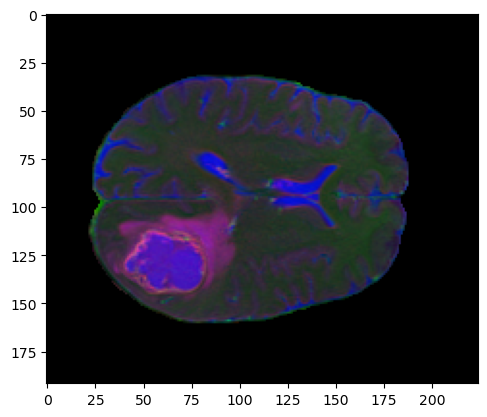

Processing frame 84


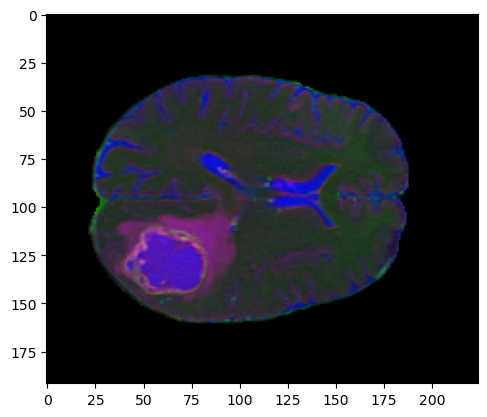

Length of mask list: (4, 192, 224, 160)
ED Mask: True, ET Mask: True, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.1473840625787475, et_scale: 0.8715477516329609
Before applying a: 0.09604484587907791, 0.07370870560407639


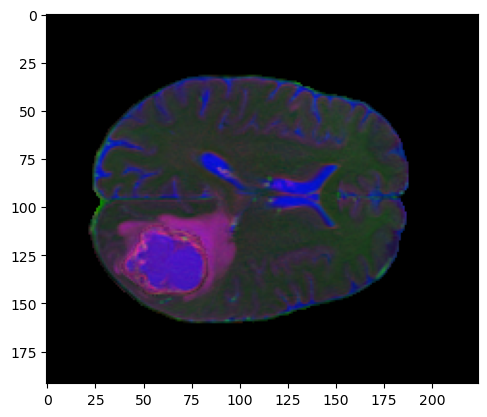

Processing frame 85
Length of mask list: (4, 192, 224, 160)
ED Mask: True, ET Mask: True, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.1328248435452772, et_scale: 0.8827490019290272
Before applying a: 0.09345737844705582, 0.07477597147226334
Processing frame 86
Length of mask list: (4, 192, 224, 160)
ED Mask: True, ET Mask: True, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.1257061157278145, et_scale: 0.8883313202517867
Before applying a: 0.09350940585136414, 0.07455513626337051
Processing frame 87
Length of mask list: (4, 192, 224, 160)
ED Mask: True, ET Mask: True, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.1257399709596096, et_scale: 0.8883046047903713
Before applying a: 0.09239257872104645, 0.0742027759552002
Processing frame 88
Length of mask list: (4, 192, 224, 160)
ED Mask: True, ET Mask: True, ed_mask shape: (192, 224), et_mask shape: (192, 224), ed_scale: 1.134121280969472, et_scale: 0.8817399133408181
Before app

array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
    

In [351]:
targeted_contrast(pred, label)

# Plot Graph

In [84]:
new = '/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/results/F_GLI/boxes/SSA_boxes.csv'
new = pd.read_csv(new)
new = clean_df(new, True, 'brats')
new.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000
mean,0.719274,0.603031,0.626057,17.957907,36.714302,23.072293,0.915512,0.741797,0.699955,0.620819,0.523327,0.610084
std,0.236030,0.194641,0.294921,25.001731,25.067353,27.338489,0.193614,0.195024,0.275776,0.247063,0.197832,0.319106
min,0.000000,0.083136,0.025818,1.414214,2.236068,1.414214,0.000000,0.110858,0.058034,0.000000,0.056321,0.014579
25%,0.618654,0.455056,0.431620,4.327624,17.273160,3.307123,0.929285,0.651736,0.697183,0.460214,0.348606,0.334098
50%,0.809420,0.624683,0.766599,6.708204,26.622681,10.000000,0.985710,0.775515,0.811105,0.712624,0.546112,0.717441
75%,0.884517,0.749187,0.846299,22.956208,55.835985,32.586967,0.994455,0.905176,0.882714,0.811195,0.648770,0.893523
max,0.954220,0.926346,0.919309,120.383553,92.362320,108.589127,0.999651,0.957049,0.961243,0.912906,0.900873,0.993398


In [74]:
new

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
0,BraTS-GLI-00000-000.npy,0.835582,0.083136,0.901135,29.546574,9.055386,2.236068,0.973505,0.158694,0.937765,0.731890,0.056321,0.867258
1,BraTS-GLI-00005-000.npy,0.945617,0.441070,0.416903,3.316625,48.093658,49.648766,0.991359,0.707266,0.782510,0.903909,0.320458,0.284144
2,BraTS-GLI-00006-000.npy,0.954220,0.431064,0.858847,3.741657,68.425140,2.236068,0.999451,0.590598,0.775976,0.912906,0.339388,0.961535
3,BraTS-GLI-00008-000.npy,0.000000,0.634967,0.075806,120.383553,92.362320,108.589127,0.000000,0.712435,0.646302,0.000000,0.572695,0.040264
4,BraTS-GLI-00016-000.npy,0.924510,0.664269,0.156600,2.236068,31.844900,4.358899,0.991891,0.772958,0.155743,0.865701,0.582378,0.157467
5,BraTS-GLI-00016-001.npy,0.260269,0.344791,0.635425,9.273619,24.372116,19.026299,0.931765,0.492351,0.835900,0.151261,0.265284,0.512509
6,BraTS-GLI-00036-001.npy,0.858315,0.845262,0.806226,6.403124,18.248287,2.236068,0.994757,0.914254,0.712782,0.754788,0.785951,0.927866
7,BraTS-GLI-00043-000.npy,0.468715,0.155867,0.237523,19.949938,20.462137,18.466185,0.992991,0.110858,0.433076,0.306755,0.262406,0.163635
8,BraTS-GLI-00064-000.npy,0.625197,0.334798,0.118091,30.225809,60.083275,31.257000,0.829014,0.486907,0.194180,0.501821,0.255104,0.084845
9,BraTS-GLI-00070-000.npy,0.936160,0.689033,0.769145,1.414214,40.509258,53.540169,0.995899,0.778071,0.840165,0.883182,0.618281,0.709196


In [391]:
new.head(53).describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,0.405936,0.382791,0.734116,73.173118,73.403494,63.867248,0.799911,0.819332,0.880339,0.316085,0.268042,0.643552
std,0.295587,0.160988,0.140347,23.221489,12.321637,25.613123,0.265620,0.109630,0.146778,0.270693,0.139598,0.144280
min,0.000000,0.053575,0.237509,26.191601,40.632500,2.236068,0.000000,0.565225,0.338929,0.000000,0.027664,0.151786
25%,0.149744,0.258660,0.697678,54.379681,65.877518,47.849739,0.811769,0.763622,0.847877,0.082896,0.151241,0.587695
50%,0.385945,0.394382,0.786810,74.632767,72.428223,69.251709,0.903393,0.845629,0.938509,0.258960,0.281038,0.675127
75%,0.658636,0.499588,0.822838,90.160965,80.535706,81.987801,0.955762,0.913679,0.968146,0.515826,0.361139,0.732660
max,0.912136,0.679024,0.886071,125.122734,99.206856,116.056023,0.996701,0.977531,0.999481,0.886182,0.585460,0.878708


In [8]:
new_stuff = '/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/results/Sin2/boxes/SSA_boxes.csv'
new_stuff = pd.read_csv(new_stuff)
new_stuff = clean_df(new_stuff, True, 'brats')
new_stuff.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000
mean,0.847985,0.825418,0.850436,5.424205,29.208003,2.388929,0.858312,0.855335,0.903173,0.866745,0.811467,0.827004
std,0.174715,0.105157,0.102789,6.058002,20.924479,2.014686,0.214353,0.145093,0.156782,0.141734,0.103082,0.079902
min,0.434109,0.612759,0.530006,1.000000,4.000000,1.000000,0.329412,0.574738,0.370637,0.498003,0.578120,0.656236
25%,0.808005,0.725633,0.845275,1.103553,6.663719,1.414214,0.884031,0.855298,0.913252,0.843994,0.807535,0.777125
50%,0.937534,0.884787,0.882281,3.072526,29.038764,1.707107,0.950810,0.921654,0.945980,0.927470,0.838260,0.832472
75%,0.961984,0.899023,0.901224,6.758130,42.865870,2.396134,0.976461,0.946044,0.970695,0.957872,0.887338,0.892507
max,0.979601,0.934232,0.933899,21.047565,61.075775,9.000000,0.993148,0.979156,0.984082,0.973663,0.908286,0.929813


In [6]:
new_s = '/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/results/F_NA_SSA/boxes/SSA_boxes.csv'
new_s = pd.read_csv(new_s)
new_s = clean_df(new_s, True, 'brats')
new_s.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,0.805436,0.694330,0.713943,9.026574,31.069491,31.608661,0.821257,0.774120,0.754574,0.823815,0.698223,0.729290
std,0.070655,0.206822,0.148969,8.167299,14.148868,17.913972,0.132409,0.262642,0.215114,0.139839,0.126486,0.159865
min,0.716191,0.207961,0.415089,3.605551,13.605056,3.162278,0.606037,0.119049,0.306372,0.583684,0.445673,0.481466
25%,0.751907,0.708101,0.635333,4.123106,19.209373,16.278820,0.788348,0.781040,0.803804,0.722612,0.631043,0.643401
50%,0.793909,0.747438,0.735230,4.577075,28.089144,36.413601,0.858044,0.850449,0.830187,0.860700,0.741785,0.721955
75%,0.866262,0.815552,0.837520,12.247449,41.701321,45.264782,0.917249,0.937572,0.864662,0.946176,0.797875,0.864120
max,0.899957,0.862101,0.876371,27.477262,53.860420,56.515484,0.981475,0.964597,0.933739,0.969553,0.821515,0.920949


In [7]:
new_s = '/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/results/F_A_SSA/boxes/SSA_boxes.csv'
new_s = pd.read_csv(new_s)
new_s = clean_df(new_s, True, 'brats')
new_s.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,0.789007,0.683269,0.681257,26.756296,39.325140,17.489977,0.892911,0.744722,0.630799,0.718973,0.689720,0.788387
std,0.061005,0.229804,0.205544,22.896250,13.102852,24.130634,0.093187,0.265658,0.243564,0.097851,0.099288,0.200902
min,0.678845,0.100792,0.178125,5.000000,14.715589,2.449490,0.767884,0.054926,0.119999,0.517631,0.515638,0.345463
25%,0.754802,0.674300,0.645428,6.403124,36.903908,3.464102,0.809155,0.781838,0.524579,0.705848,0.611042,0.806818
50%,0.781938,0.740656,0.734705,22.226110,40.311287,4.242640,0.945472,0.785982,0.644934,0.714045,0.695602,0.857002
75%,0.822273,0.776796,0.769057,47.520000,50.575169,16.982157,0.969171,0.859018,0.791709,0.749449,0.770302,0.924941
max,0.891693,0.860235,0.859419,60.415230,53.499428,60.613529,0.985900,0.941886,0.963872,0.843703,0.817635,0.949631


In [4]:
new_s = '/scratch-second/FYP/F_NA_GLI/F_NA_GLI.csv'
new_s = pd.read_csv(new_s)
new_s = clean_df(new_s, True, 'brats')
new_s.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000
mean,0.761910,0.767276,0.822630,10.532741,30.918457,21.573367,0.832122,0.896953,0.883232,0.746754,0.691130,0.787499
std,0.213896,0.133531,0.149677,18.058163,25.080794,29.325421,0.235366,0.128655,0.149630,0.185006,0.153686,0.167896
min,0.000000,0.245755,0.000000,1.000000,1.732051,1.000000,0.000000,0.391617,0.000000,0.000000,0.157003,0.000000
25%,0.720184,0.721089,0.803966,2.236068,7.060415,1.414214,0.775509,0.872536,0.867532,0.673583,0.642286,0.750000
50%,0.831515,0.807474,0.874480,4.358899,25.806976,3.316625,0.940500,0.947911,0.918298,0.807636,0.725264,0.842521
75%,0.904854,0.863916,0.905837,8.602325,50.289165,39.761791,0.982449,0.978488,0.955182,0.871997,0.793235,0.896248
max,0.969399,0.933544,0.948309,94.867538,100.621071,110.263321,1.000000,0.999467,0.998639,0.978761,0.945746,0.976366


In [15]:
worst_in_na_ssa = new_s[(new_s['dice_ED'] < 0.7) & (new_s['dice_ET'] < 0.7) & (new_s['dice_NCR'] < 0.7)]
worst_in_na_ssa

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
25,BraTS-GLI-00204-000.npy,0.684088,0.603225,0.637309,6.636997,9.000000,19.000000,0.695396,0.467787,0.904902,0.673143,0.849052,0.491859
115,BraTS-GLI-01149-000.npy,0.000000,0.694941,0.414125,14.732537,7.060415,53.879475,0.000000,0.577692,0.925837,0.000000,0.871904,0.266713
134,BraTS-GLI-01273-000.npy,0.064176,0.404117,0.527299,74.556252,84.318443,5.385165,0.034128,0.464635,0.998639,0.536765,0.357547,0.358224
162,BraTS-GLI-01441-000.npy,0.552480,0.594831,0.010801,65.930649,57.349804,72.378174,0.885194,0.847695,0.007287,0.401550,0.458163,0.020857
167,BraTS-GLI-01506-000.npy,0.500530,0.541868,0.301560,21.095022,17.120150,14.456832,0.657356,0.418496,0.179706,0.404119,0.768387,0.936743
168,BraTS-GLI-01508-000.npy,0.259108,0.510440,0.031716,19.000000,68.330078,76.741127,0.167714,0.550737,0.024924,0.569397,0.475638,0.043593
170,BraTS-GLI-01513-000.npy,0.375032,0.509279,0.698564,12.727922,51.405746,10.153704,0.232688,0.892854,0.674257,0.965919,0.356237,0.724688
171,BraTS-GLI-01522-000.npy,0.147660,0.687115,0.677282,7.861251,92.314682,37.322914,0.082810,0.894419,0.986558,0.680851,0.557826,0.515636


In [12]:
worst_in_na_ssa = new_s[(new_s['dice_ED'] > 0.85) & (new_s['dice_ET'] > 0.85) & (new_s['dice_NCR'] > 0.85)]['name'].to_list()
worst_in_na_ssa

['BraTS-GLI-00118-000.npy',
 'BraTS-GLI-00282-000.npy',
 'BraTS-GLI-00318-000.npy',
 'BraTS-GLI-00347-000.npy',
 'BraTS-GLI-00456-000.npy',
 'BraTS-GLI-00479-001.npy',
 'BraTS-GLI-00548-000.npy',
 'BraTS-GLI-00554-000.npy',
 'BraTS-GLI-00569-000.npy',
 'BraTS-GLI-00580-000.npy',
 'BraTS-GLI-00605-000.npy',
 'BraTS-GLI-00663-000.npy',
 'BraTS-GLI-00686-000.npy',
 'BraTS-GLI-00714-000.npy',
 'BraTS-GLI-00777-001.npy',
 'BraTS-GLI-00804-000.npy',
 'BraTS-GLI-01045-000.npy',
 'BraTS-GLI-01062-000.npy',
 'BraTS-GLI-01085-000.npy',
 'BraTS-GLI-01122-000.npy',
 'BraTS-GLI-01384-000.npy']

In [13]:
new_s.head(40)

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
0,BraTS-GLI-00002-000.npy,0.879566,0.788919,0.801464,4.358899,6.164414,3.316625,0.887269,0.722284,0.759376,0.871997,0.869097,0.848491
1,BraTS-GLI-00003-000.npy,0.944492,0.782466,0.900265,2.236068,68.898476,3.162278,0.991925,0.971578,0.937943,0.901388,0.654978,0.865497
2,BraTS-GLI-00021-001.npy,0.800408,0.818523,0.662459,3.605551,3.605551,22.912878,0.718371,0.817158,0.711019,0.903597,0.819893,0.620108
3,BraTS-GLI-00022-001.npy,0.921616,0.802618,0.834318,2.000000,25.806976,67.441818,0.993205,0.973661,0.939881,0.859654,0.682689,0.750074
4,BraTS-GLI-00035-000.npy,0.885590,0.761576,0.895159,1.414214,51.705902,1.000000,0.997197,0.964203,0.890876,0.796450,0.629324,0.899482
5,BraTS-GLI-00053-001.npy,0.811017,0.897018,0.916576,5.000000,36.958065,1.414214,0.982995,0.978287,0.891214,0.690255,0.828217,0.943424
6,BraTS-GLI-00056-000.npy,0.676964,0.802276,0.906016,4.358899,25.787594,2.236068,0.856084,0.982964,0.884585,0.559830,0.677701,0.928511
7,BraTS-GLI-00058-000.npy,0.852587,0.750429,0.890357,5.099020,15.684387,1.732051,0.985704,0.887795,0.901713,0.751147,0.649875,0.879283
8,BraTS-GLI-00060-000.npy,0.906667,0.840386,0.876558,2.828427,39.118408,2.236068,0.975315,0.961365,0.899078,0.847046,0.746452,0.855139
9,BraTS-GLI-00061-001.npy,0.601618,0.807474,0.565224,9.433981,4.375818,12.175678,0.782905,0.862651,0.527867,0.488502,0.758931,0.608272


In [15]:
new_s = '/scratch-second/FYP/F_A_GLI/F_A_GLI.csv'
new_s = pd.read_csv(new_s)
new_s = clean_df(new_s, True, 'brats')
new_s.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000
mean,0.755348,0.777396,0.826226,16.587943,26.893294,8.792202,0.805546,0.760458,0.853230,0.754477,0.824873,0.828042
std,0.228651,0.167748,0.154011,24.939504,26.318354,18.797517,0.250978,0.189888,0.179822,0.202209,0.148302,0.137310
min,0.005626,0.101208,0.000000,1.000000,1.000000,1.000000,0.003125,0.053564,0.000000,0.013171,0.308161,0.000000
25%,0.718375,0.710838,0.810651,3.000000,4.123106,1.414214,0.750838,0.662067,0.836539,0.712942,0.776857,0.793534
50%,0.844576,0.844045,0.875635,4.898980,15.132746,2.000000,0.919042,0.817094,0.915447,0.821301,0.883119,0.854506
75%,0.903561,0.897178,0.907598,12.124355,48.093658,4.690416,0.971081,0.896370,0.950860,0.884063,0.928801,0.909149
max,0.978188,0.960232,0.955813,98.840019,122.511635,94.206161,0.996989,0.980493,0.995463,0.991015,0.975763,0.990601


In [17]:
new_s = '/scratch-second/FYP/F_NA_SSA/F_NA_SSA_boxes.csv'
new_s = pd.read_csv(new_s)
new_s = clean_df(new_s, True, 'brats')
new_s.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
mean,0.562230,0.704237,0.699124,19.229366,36.670839,43.073952,0.678370,0.799014,0.700109,0.597979,0.668260,0.761449
std,0.304777,0.187032,0.180374,21.565548,19.362164,27.558699,0.299083,0.172904,0.229473,0.325607,0.198702,0.138108
min,0.000000,0.197533,0.029358,1.732051,4.242640,2.828427,0.000000,0.148753,0.015023,0.000000,0.114671,0.272535
25%,0.301277,0.614104,0.613687,5.099020,19.722460,18.486267,0.548555,0.740458,0.548483,0.337301,0.554470,0.677835
50%,0.687679,0.745696,0.735788,8.425313,39.358259,45.872793,0.787757,0.839115,0.757856,0.706190,0.710015,0.793712
75%,0.815957,0.846970,0.809943,28.713748,49.749126,59.645657,0.922657,0.913093,0.885311,0.857801,0.827729,0.871103
max,0.905854,0.919427,0.927476,94.651108,82.097504,97.082436,0.995147,0.975560,0.983703,0.994987,0.907823,0.970009


In [18]:
new_s = '/scratch-second/FYP/F_A_SSA/F_A_SSA_boxes.csv'
new_s = pd.read_csv(new_s)
new_s = clean_df(new_s, True, 'brats')
new_s.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
mean,0.539184,0.678482,0.673811,28.447943,42.863312,27.496050,0.730605,0.698462,0.613384,0.505547,0.688305,0.821888
std,0.315327,0.207484,0.208210,29.247785,15.018776,29.688976,0.299020,0.191393,0.252881,0.322581,0.228094,0.162159
min,0.000000,0.009518,0.000000,2.236068,18.611818,2.236068,0.000000,0.009078,0.000000,0.000000,0.010003,0.000000
25%,0.198611,0.572694,0.550364,6.972448,33.529859,5.313628,0.696684,0.578759,0.447972,0.236827,0.590283,0.755576
50%,0.699319,0.731916,0.735710,13.204940,43.667210,10.315073,0.837896,0.785038,0.633140,0.598161,0.746654,0.867071
75%,0.776183,0.833487,0.816210,45.141060,51.049751,45.807960,0.936372,0.845121,0.831071,0.749785,0.857925,0.930034
max,0.921397,0.901478,0.926420,115.966805,87.647018,96.311996,1.000000,0.906144,0.980011,0.992392,0.934758,0.970434


In [21]:
new_s = '/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/results/F_A_SSA/boxes/SSA_boxes.csv'
new_s = pd.read_csv(new_s)
new_s = clean_df(new_s, True, 'brats')
new_s.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,0.560624,0.674568,0.665424,31.180353,42.678834,26.848113,0.772100,0.709130,0.613284,0.514223,0.678692,0.812512
std,0.320944,0.206779,0.224647,29.237673,15.403028,30.388616,0.280669,0.198503,0.269514,0.327003,0.214769,0.178940
min,0.000000,0.009547,0.000000,2.236068,14.696939,2.236068,0.000000,0.009106,0.000000,0.000000,0.010032,0.000000
25%,0.174899,0.601592,0.552647,7.348469,34.029400,4.000000,0.725896,0.600261,0.452898,0.193439,0.590290,0.749642
50%,0.719204,0.729536,0.745009,22.226110,43.669212,7.549834,0.867896,0.785957,0.658583,0.621764,0.712763,0.860261
75%,0.784586,0.825456,0.811207,49.859802,51.865211,48.135227,0.945472,0.835946,0.833805,0.749465,0.836116,0.929968
max,0.921369,0.888355,0.926420,115.966805,87.651299,96.311996,1.000000,0.941902,0.980011,0.992392,0.925279,0.970431


In [ ]:
new_s = '/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/results/F_A_SSA/boxes/SSA_boxes.csv'
new_s = pd.read_csv(new_s)
new_s = clean_df(new_s, True, 'brats')
new_s.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,0.789007,0.683269,0.681257,26.756296,39.325140,17.489977,0.892911,0.744722,0.630799,0.718973,0.689720,0.788387
std,0.061005,0.229804,0.205544,22.896250,13.102852,24.130634,0.093187,0.265658,0.243564,0.097851,0.099288,0.200902
min,0.678845,0.100792,0.178125,5.000000,14.715589,2.449490,0.767884,0.054926,0.119999,0.517631,0.515638,0.345463
25%,0.754802,0.674300,0.645428,6.403124,36.903908,3.464102,0.809155,0.781838,0.524579,0.705848,0.611042,0.806818
50%,0.781938,0.740656,0.734705,22.226110,40.311287,4.242640,0.945472,0.785982,0.644934,0.714045,0.695602,0.857002
75%,0.822273,0.776796,0.769057,47.520000,50.575169,16.982157,0.969171,0.859018,0.791709,0.749449,0.770302,0.924941
max,0.891693,0.860235,0.859419,60.415230,53.499428,60.613529,0.985900,0.941886,0.963872,0.843703,0.817635,0.949631
